In [1]:
# ── Install dependencies if needed ──────────────────────────────────────────
!pip install pandas numpy scipy networkx tqdm

In [2]:
import pandas as pd
import numpy as np


from google.colab import drive
drive.mount('/content/drive')

DATA_DIR = "/content/drive/MyDrive/phenotype-drug/"

nodes = pd.read_csv(DATA_DIR + "nodes.csv")
edges = pd.read_csv(DATA_DIR + "edges.csv")
kg = pd.read_csv(DATA_DIR + "kg.csv")

print("=" * 60)
print("NODES — shape:", nodes.shape)
print(nodes.dtypes)
print(nodes.head(3))
print("\nnode_type value counts:")
print(nodes["node_type"].value_counts())

Mounted at /content/drive


/tmp/ipykernel_1148/3416543266.py:12: DtypeWarning: Columns (3,8) have mixed types. Specify dtype option on import or set low_memory=False.
  kg = pd.read_csv(DATA_DIR + "kg.csv")


NODES — shape: (129375, 5)
node_index      int64
node_id        object
node_type      object
node_name      object
node_source    object
dtype: object
   node_index node_id     node_type node_name node_source
0           0    9796  gene/protein    PHYHIP        NCBI
1           1    7918  gene/protein    GPANK1        NCBI
2           2    8233  gene/protein     ZRSR2        NCBI

node_type value counts:
node_type
biological_process    28642
gene/protein          27671
disease               17080
effect/phenotype      15311
anatomy               14035
molecular_function    11169
drug                   7957
cellular_component     4176
pathway                2516
exposure                818
Name: count, dtype: int64


In [3]:
print("=" * 60)
print("EDGES — shape:", edges.shape)
print(edges.dtypes)
print(edges.head(3))
print("\nrelation value counts (top 20):")
print(edges["relation"].value_counts().head(20))

EDGES — shape: (8100498, 4)
relation            object
display_relation    object
x_index              int64
y_index              int64
dtype: object
          relation display_relation  x_index  y_index
0  protein_protein              ppi        0     8889
1  protein_protein              ppi        1     2798
2  protein_protein              ppi        2     5646

relation value counts (top 20):
relation
anatomy_protein_present       3036406
drug_drug                     2672628
protein_protein                642150
disease_phenotype_positive     300634
bioprocess_protein             289610
cellcomp_protein               166804
disease_protein                160822
molfunc_protein                139060
drug_effect                    129568
bioprocess_bioprocess          105772
pathway_protein                 85292
disease_disease                 64388
contraindication                61350
drug_protein                    51306
anatomy_protein_absent          39774
phenotype_phenotype   

In [4]:
print("=" * 60)
print("KG — shape:", kg.shape)
print(kg.dtypes)
print(kg.head(3))
print("\nrelation value counts (top 20):")
print(kg["relation"].value_counts().head(20))

KG — shape: (8100498, 12)
relation            object
display_relation    object
x_index              int64
x_id                object
x_type              object
x_name              object
x_source            object
y_index              int64
y_id                object
y_type              object
y_name              object
y_source            object
dtype: object
          relation display_relation  x_index  x_id        x_type  x_name  \
0  protein_protein              ppi        0  9796  gene/protein  PHYHIP   
1  protein_protein              ppi        1  7918  gene/protein  GPANK1   
2  protein_protein              ppi        2  8233  gene/protein   ZRSR2   

  x_source  y_index   y_id        y_type y_name y_source  
0     NCBI     8889  56992  gene/protein  KIF15     NCBI  
1     NCBI     2798   9240  gene/protein  PNMA1     NCBI  
2     NCBI     5646  23548  gene/protein  TTC33     NCBI  

relation value counts (top 20):
relation
anatomy_protein_present       3036406
drug_drug      

In [8]:
# Inspect the relation names — adjust the string values below if yours differ
# We need:
#   INDICATION_REL  : drug → disease  (e.g. "indication")
#   PHENOTYPE_REL   : disease → phenotype (e.g. "disease_phenotype_positive")

print("All unique relations in kg.csv:")
for r in sorted(kg["relation"].unique()):
    print(" ", r)

All unique relations in kg.csv:
  anatomy_anatomy
  anatomy_protein_absent
  anatomy_protein_present
  bioprocess_bioprocess
  bioprocess_protein
  cellcomp_cellcomp
  cellcomp_protein
  contraindication
  disease_disease
  disease_phenotype_negative
  disease_phenotype_positive
  disease_protein
  drug_drug
  drug_effect
  drug_protein
  exposure_bioprocess
  exposure_cellcomp
  exposure_disease
  exposure_exposure
  exposure_molfunc
  exposure_protein
  indication
  molfunc_molfunc
  molfunc_protein
  off-label use
  pathway_pathway
  pathway_protein
  phenotype_phenotype
  phenotype_protein
  protein_protein


In [7]:
INDICATION_REL = "indication"                  # drug-disease indication edge
PHENOTYPE_REL  = "disease_phenotype_positive"  # disease-phenotype edge

# Node type strings (check nodes["node_type"].value_counts() above)
DRUG_TYPE      = "drug"
DISEASE_TYPE   = "disease"
PHENOTYPE_TYPE = "effect/phenotype"


# Column names in kg.csv
SRC_COL   = "x_index"   # source node index
DST_COL   = "y_index"   # destination node index
REL_COL   = "relation"

print(f"Indication edges  : {(kg[REL_COL] == INDICATION_REL).sum()}")
print(f"Phenotype edges   : {(kg[REL_COL] == PHENOTYPE_REL).sum()}")
print(f"Drug nodes        : {(nodes['node_type'] == DRUG_TYPE).sum()}")
print(f"Disease nodes     : {(nodes['node_type'] == DISEASE_TYPE).sum()}")
print(f"Phenotype nodes   : {(nodes['node_type'] == PHENOTYPE_TYPE).sum()}")

Indication edges  : 18776
Phenotype edges   : 300634
Drug nodes        : 7957
Disease nodes     : 17080
Phenotype nodes   : 15311


In [8]:
from collections import defaultdict

# disease_phenotype_positive edges  (disease ↔ phenotype, treat as undirected)
phen_edges = kg[kg[REL_COL] == PHENOTYPE_REL]
disease_to_phenotypes = defaultdict(set)
for _, row in phen_edges.iterrows():
    disease_to_phenotypes[row[SRC_COL]].add(row[DST_COL])
    disease_to_phenotypes[row[DST_COL]].add(row[SRC_COL])  # undirected

# indication edges  (drug → disease)
ind_edges = kg[kg[REL_COL] == INDICATION_REL]
disease_to_drugs = defaultdict(set)
for _, row in ind_edges.iterrows():
    # x is drug, y is disease — store drug index under that disease
    disease_to_drugs[row[DST_COL]].add(row[SRC_COL])

print(f"Diseases with ≥1 phenotype : {len(disease_to_phenotypes)}")
print(f"Diseases with ≥1 drug      : {len(disease_to_drugs)}")

# Eligible diseases: have BOTH
eligible = set(disease_to_phenotypes.keys()) & set(disease_to_drugs.keys())
print(f"Eligible diseases (both)   : {len(eligible)}")



Diseases with ≥1 phenotype : 16148
Diseases with ≥1 drug      : 3164
Eligible diseases (both)   : 539


In [5]:
import json

# 看文件格式
print("=== test_disease_ids.txt ===")
with open("/content/test_disease_ids.txt") as f:
    lines = f.readlines()[:5]
    print(lines)

print("\n=== train_disease_ids.txt ===")
with open("/content/train_disease_ids.txt") as f:
    lines = f.readlines()[:5]
    print(lines)

print("\n=== test_drug_pairs.csv ===")
print(pd.read_csv("/content/test_drug_pairs.csv").head(3))
print(pd.read_csv("/content/test_drug_pairs.csv").columns.tolist())

print("\n=== train_drug_pairs.csv ===")
print(pd.read_csv("/content/train_drug_pairs.csv").head(3))
print(pd.read_csv("/content/train_drug_pairs.csv").columns.tolist())

print("\n=== split_stats.json ===")
with open("/content/split_stats.json") as f:
    print(json.load(f))


=== test_disease_ids.txt ===


FileNotFoundError: [Errno 2] No such file or directory: '/content/test_disease_ids.txt'

In [9]:
# Load predefined train/test split
import random
random.seed(42)
np.random.seed(42)

eligible_list = sorted(eligible)
random.shuffle(eligible_list)

split = int(0.8 * len(eligible_list))
train_diseases = set(eligible_list[:split])
test_diseases  = set(eligible_list[split:])

print(f"Train diseases: {len(train_diseases)}")
print(f"Test  diseases: {len(test_diseases)}")

# All drug node indices
drug_indices = set(nodes[nodes["node_type"] == DRUG_TYPE]["node_index"].tolist())
print(f"Total drug nodes: {len(drug_indices)}")
train_diseases = set(
    int(x.strip()) for x in open(DATA_DIR + "train_disease_ids.txt").readlines()
)
test_diseases = set(
    int(x.strip()) for x in open(DATA_DIR + "test_disease_ids.txt").readlines()
)
test_pairs  = pd.read_csv(DATA_DIR + "test_drug_pairs.csv")
train_pairs = pd.read_csv(DATA_DIR + "train_drug_pairs.csv")

print(f"Train diseases: {len(train_diseases)}")
print(f"Test diseases: {len(test_diseases)}")
print(f"Train pairs: {len(train_pairs)}")
print(f"Test pairs: {len(test_pairs)}")

Train diseases: 431
Test  diseases: 108
Total drug nodes: 7957
Train diseases: 431
Test diseases: 108
Train pairs: 5406
Test pairs: 1568


In [10]:
# 找出test disease节点的所有incident edges，建图时排除
test_disease_set = test_diseases  # 已经在Cell 4定义了

# 过滤掉test disease参与的边
kg_train = kg[
    (~kg[SRC_COL].isin(test_disease_set)) &
    (~kg[DST_COL].isin(test_disease_set))
]

# 然后用 kg_train 而不是 kg 来建adjacency matrix
src = kg_train[SRC_COL].values
dst = kg_train[DST_COL].values

In [27]:
from scipy.sparse import csr_matrix
import scipy.sparse as sp

N = len(nodes)   # total number of nodes
print(f"Total nodes: {N}")

# Build undirected adjacency from ALL edges in kg.csv
##src = kg[SRC_COL].values
dst = kg[DST_COL].values

# Symmetrise (undirected)
rows = np.concatenate([src, dst])
cols = np.concatenate([dst, src])
data = np.ones(len(rows), dtype=np.float32)

A = csr_matrix((data, (rows, cols)), shape=(N, N))

# Row-normalise  (each row sums to 1)
row_sums = np.array(A.sum(axis=1)).flatten()
row_sums[row_sums == 0] = 1   # avoid div-by-zero for isolated nodes
D_inv = sp.diags(1.0 / row_sums)

A_norm = D_inv @ A

print("Adjacency matrix built — shape:", A_norm.shape)
print(f"Non-zeros: {A_norm.nnz:,}")

Total nodes: 129375
Adjacency matrix built — shape: (129375, 129375)
Non-zeros: 11,403,345


In [26]:
def ppr_scores(seed_indices, A_norm, alpha=0.15, max_iter=50, tol=1e-6):
    """
    Compute Personalized PageRank scores for a set of seed nodes.

    Parameters
    ----------
    seed_indices : list of int   — phenotype node indices as seeds
    A_norm       : csr_matrix    — row-normalised adjacency (N x N)
    alpha        : float         — restart probability (default 0.15)
    max_iter     : int           — maximum power iterations
    tol          : float         — convergence threshold

    Returns
    -------
    r : np.ndarray of shape (N,) — PPR score for every node
    """
    N = A_norm.shape[0]

    # Seed vector: uniform over seed nodes
    s = np.zeros(N, dtype=np.float32)
    if len(seed_indices) == 0:
        return s
    s[seed_indices] = 1.0 / len(seed_indices)

    r = s.copy()
    A_T = A_norm.T   # transpose for column-stochastic propagation

    for _ in range(max_iter):
        r_new = (1 - alpha) * A_T.dot(r) + alpha * s
        if np.linalg.norm(r_new - r, 1) < tol:
            break
        r = r_new

    return r_new

print("PPR function defined.")

PPR function defined.


In [20]:
def recall_at_k(ranked_drugs, true_drugs, k):
    """Fraction of true drugs found in the top-k ranked list."""
    top_k = set(ranked_drugs[:k])
    hits  = len(top_k & set(true_drugs))
    return hits / len(true_drugs) if true_drugs else 0.0

def reciprocal_rank(ranked_drugs, true_drugs):
    """Reciprocal rank of the first true drug in the ranked list."""
    true_set = set(true_drugs)
    for rank, d in enumerate(ranked_drugs, start=1):
        if d in true_set:
            return 1.0 / rank
    return 0.0

print("Metrics defined.")

Metrics defined.


In [28]:
from tqdm import tqdm

drug_indices_arr = np.array(sorted(drug_indices))  # fixed ordering for slicing

results = []

for disease_idx in tqdm(test_diseases, desc="Evaluating PPR"):
    # --- inputs ---
    seed_nodes = list(disease_to_phenotypes.get(disease_idx, []))
    true_drugs  = list(disease_to_drugs.get(disease_idx, []))

    if not seed_nodes or not true_drugs:
        continue

    # --- PPR ---
    scores = ppr_scores(seed_nodes, A_norm, alpha=0.15)

    # --- rank drugs by PPR score (descending) ---
    drug_scores  = scores[drug_indices_arr]
    sorted_order = np.argsort(-drug_scores)          # descending
    ranked_drugs = drug_indices_arr[sorted_order].tolist()

    results.append({
        "disease"   : disease_idx,
        "n_seeds"   : len(seed_nodes),
        "n_true"    : len(true_drugs),
        "R@1"       : recall_at_k(ranked_drugs, true_drugs, 1),
        "R@5"       : recall_at_k(ranked_drugs, true_drugs, 5),
        "R@10"      : recall_at_k(ranked_drugs, true_drugs, 10),
        "MRR"       : reciprocal_rank(ranked_drugs, true_drugs),
    })

results_df = pd.DataFrame(results)
print(f"\nEvaluated on {len(results_df)} test diseases")
results_df.head()

Evaluating PPR: 100%|██████████| 108/108 [01:19<00:00,  1.36it/s]


Evaluated on 108 test diseases


,disease,n_seeds,n_true,R@1,R@5,R@10,MRR
0,37888,2,87,0.0,0.0,0.0,0.028571
1,83972,1,3,0.0,0.0,0.0,0.005988
2,31245,55,2,0.0,0.0,0.0,0.001645
3,33296,11,3,0.0,0.0,0.0,0.043478
4,29715,15,8,0.0,0.0,0.0,0.027027


In [29]:
print("=" * 40)
print("PPR Baseline — Test Set Results")
print("=" * 40)
for metric in ["R@1", "R@5", "R@10", "MRR"]:
    mean_val = results_df[metric].mean()
    std_val  = results_df[metric].std()
    print(f"  {metric:<6} : {mean_val:.4f}  ±  {std_val:.4f}")

print(f"\nMedian seeds per disease : {results_df['n_seeds'].median():.1f}")
print(f"Median true drugs        : {results_df['n_true'].median():.1f}")

PPR Baseline — Test Set Results
  R@1    : 0.0000  ±  0.0000
  R@5    : 0.0000  ±  0.0000
  R@10   : 0.0325  ±  0.1679
  MRR    : 0.0193  ±  0.0341

Median seeds per disease : 13.0
Median true drugs        : 3.0


In [30]:
alphas = [0.05, 0.10, 0.15, 0.20, 0.30, 0.50, 0.75]
alpha_results = []

# Run on a small sample for speed
sample_diseases = list(test_diseases)[:30]

for alpha in alphas:
    r1_list, mrr_list = [], []
    for disease_idx in sample_diseases:
        seed_nodes = list(disease_to_phenotypes.get(disease_idx, []))
        true_drugs  = list(disease_to_drugs.get(disease_idx, []))
        if not seed_nodes or not true_drugs:
            continue
        scores       = ppr_scores(seed_nodes, A_norm, alpha=alpha)
        drug_scores  = scores[drug_indices_arr]
        sorted_order = np.argsort(-drug_scores)
        ranked_drugs = drug_indices_arr[sorted_order].tolist()
        r1_list.append(recall_at_k(ranked_drugs, true_drugs, 1))
        mrr_list.append(reciprocal_rank(ranked_drugs, true_drugs))
    alpha_results.append({"alpha": alpha,
                          "R@1":   np.mean(r1_list),
                          "MRR":   np.mean(mrr_list)})

alpha_df = pd.DataFrame(alpha_results)
print(alpha_df.to_string(index=False))

 alpha  R@1      MRR
  0.05  0.0 0.009220
  0.10  0.0 0.012879
  0.15  0.0 0.013778
  0.20  0.0 0.013465
  0.30  0.0 0.013711
  0.50  0.0 0.014304
  0.75  0.0 0.014731


In [31]:
# 补PPR的R@50, AUROC, balanced AUPRC
from sklearn.metrics import roc_auc_score, average_precision_score

ppr_full = []
ppr_bal_labels = []
ppr_bal_scores = []
np.random.seed(42)

for d in tqdm(test_diseases, desc="PPR full metrics"):
    ph = list(disease_to_phenotypes.get(d, []))
    td = list(test_disease_to_drugs.get(d, []))
    if not ph or not td: continue
    td_set = set(td)

    scores = ppr_scores(ph, A_norm, alpha=0.15)
    drug_sc = scores[drug_indices_arr]
    rd = drug_indices_arr[np.argsort(-drug_sc)].tolist()
    labels = np.array([1 if x in td_set else 0 for x in drug_indices_arr])

    ppr_full.append({
        "R@50": recall_at_k(rd, td, 50),
        "AUROC": roc_auc_score(labels, drug_sc) if 0 < labels.sum() < len(labels) else None,
    })

    # Balanced 1:1
    pos = list(td_set)
    neg = list(np.random.choice([x for x in drug_indices_arr if x not in td_set], size=len(pos), replace=False))
    ppr_bal_labels.extend([1]*len(pos) + [0]*len(neg))
    ppr_bal_scores.extend(scores[pos + neg].tolist())

pdf = pd.DataFrame(ppr_full)
print(f"PPR R@50:            {pdf['R@50'].mean():.4f}")
print(f"PPR AUROC (per-dis): {pdf['AUROC'].dropna().mean():.4f}")
print(f"PPR AUPRC (bal 1:1): {average_precision_score(ppr_bal_labels, ppr_bal_scores):.4f}")
print(f"PPR AUROC (bal 1:1): {roc_auc_score(ppr_bal_labels, ppr_bal_scores):.4f}")

PPR full metrics: 100%|██████████| 108/108 [01:19<00:00,  1.36it/s]

PPR R@50:            0.0882
PPR AUROC (per-dis): 0.8115
PPR AUPRC (bal 1:1): 0.7904
PPR AUROC (bal 1:1): 0.8302


In [32]:
# 确认load正确的model
model.load_state_dict(torch.load(DATA_DIR + "best_model.pt"))
model.eval()

balanced_labels = []
balanced_scores = []
np.random.seed(42)

with torch.no_grad():
    ne = model.encode(edge_index, edge_type)
    for d in tqdm(test_diseases):
        ph = list(disease_to_phenotypes.get(d, []))
        td = set(test_disease_to_drugs.get(d, []))
        if not ph or not td: continue

        pos = list(td)
        neg = list(np.random.choice([x for x in drug_indices_arr if x not in td], size=len(pos), replace=False))
        eval_drugs = pos + neg
        eval_labels = [1]*len(pos) + [0]*len(neg)

        eval_t = torch.tensor(eval_drugs, dtype=torch.long, device=DEVICE)
        cp, cm = pad_pheno_batch([ph]*len(eval_drugs), DEVICE)
        sc = model.score(ne, eval_t, cp, cm).cpu().numpy()

        balanced_labels.extend(eval_labels)
        balanced_scores.extend(sc.tolist())

print(f"Model AUPRC (balanced): {average_precision_score(balanced_labels, balanced_scores):.4f}")
print(f"Model AUROC (balanced): {roc_auc_score(balanced_labels, balanced_scores):.4f}")

100%|██████████| 108/108 [00:00<00:00, 287.29it/s]

Model AUPRC (balanced): 0.5942
Model AUROC (balanced): 0.6534


In [ ]:
results_df.to_csv(DATA_DIR + "ppr_baseline_results.csv", index=False)
alpha_df.to_csv(DATA_DIR  + "ppr_alpha_sensitivity.csv",  index=False)
print("Results saved.")

Results saved.


In [ ]:
# 运行这个诊断
print("drug node_index 范围:")
drug_nodes = nodes[nodes["node_type"] == "drug"]
print(drug_nodes["node_index"].min(), "~", drug_nodes["node_index"].max())

print("\ndisease node_index 范围:")
disease_nodes = nodes[nodes["node_type"] == "disease"]
print(disease_nodes["node_index"].min(), "~", disease_nodes["node_index"].max())

print("\nphenotype node_index 范围:")
phen_nodes = nodes[nodes["node_type"] == "effect/phenotype"]
print(phen_nodes["node_index"].min(), "~", phen_nodes["node_index"].max())

print("\n--- 检查eligible diseases实际内容 ---")
print(f"eligible diseases数量: {len(eligible)}")
sample_disease = list(eligible)[:3]
for d in sample_disease:
    phenotypes = disease_to_phenotypes.get(d, set())
    drugs = disease_to_drugs.get(d, set())
    print(f"  disease {d}: {len(phenotypes)} phenotypes, {len(drugs)} drugs")

print("\n--- 检查PPR scores ---")
# 手动跑一个disease看scores
test_d = list(test_diseases)[0]
seeds = list(disease_to_phenotypes.get(test_d, []))
print(f"Test disease {test_d}, seeds: {seeds[:5]}")
scores = ppr_scores(seeds, A_norm, alpha=0.15)
print(f"Max score: {scores.max():.6f}")
print(f"Score at drug nodes (first 5): {scores[drug_indices_arr[:5]]}")
print(f"Non-zero scores total: {(scores > 0).sum()}")

drug node_index 范围:
14012 ~ 39897

disease node_index 范围:
27158 ~ 100027

phenotype node_index 范围:
22117 ~ 94550

--- 检查eligible diseases实际内容 ---
eligible diseases数量: 539
  disease 28673: 16 phenotypes, 0 drugs
  disease 83972: 1 phenotypes, 3 drugs
  disease 30725: 20 phenotypes, 0 drugs

--- 检查PPR scores ---
Test disease 37888, seeds: [25610, 23083]
Max score: 0.075079
Score at drug nodes (first 5): [2.6274669e-05 4.6355063e-07 2.6710602e-04 2.1607391e-05 3.7611251e-05]
Non-zero scores total: 129375


In [20]:
# 检查disease_to_drugs里存的是什么
test_d = list(test_diseases)[0]
true_drugs = list(disease_to_drugs.get(test_d, []))
print(f"disease {test_d} 的 true drug indices: {true_drugs}")

# 确认这些index在drug_indices_arr里
print(f"这些drug index在drug_indices_arr里吗: {[d in drug_indices for d in true_drugs]}")

# 看PPR给这些drug打了多少分
print(f"PPR scores for true drugs: {scores[true_drugs]}")

# 看ranked list里true drug排第几
drug_scores_arr = scores[drug_indices_arr]
sorted_order = np.argsort(-drug_scores_arr)
ranked_drugs = drug_indices_arr[sorted_order].tolist()
for td in true_drugs:
    rank = ranked_drugs.index(td) + 1
    print(f"  drug {td} rank: {rank} / {len(ranked_drugs)}")
    seeds = list(disease_to_phenotypes.get(test_d, []))
print(f"\nSeeds: {seeds}")
print("Seed node types:")
for s in seeds[:5]:
    node_info = nodes[nodes["node_index"] == s]
    print(f"  index {s}: {node_info['node_type'].values}")

disease 37888 的 true drug indices: [14336, 15877, 14881, 14381, 14898, 14942, 15460, 14950, 16490, 14960, 14983, 15500, 14990, 15511, 15003, 20157, 14014, 16063, 16066, 14018, 14020, 14019, 14023, 14024, 14028, 14030, 14034, 14036, 14038, 15064, 14042, 15586, 15086, 15089, 19700, 15098, 14591, 15104, 14599, 14607, 15122, 15132, 15660, 18755, 15171, 20294, 20295, 14154, 17229, 20302, 14159, 17232, 17233, 17230, 17235, 17231, 17237, 17241, 17243, 17245, 17246, 20321, 17252, 20326, 17256, 15210, 17258, 17259, 14193, 15241, 15251, 14232, 15260, 15783, 14249, 16306, 14262, 14266, 14269, 14783, 16331, 14295, 20458, 20463, 14320, 20464, 20465]


NameError: name 'drug_indices' is not defined

In [ ]:
print("=" * 40)
print("PPR Baseline — Test Set Results")
print("=" * 40)
for metric in ["R@1", "R@5", "R@10", "MRR"]:
    mean_val = results_df[metric].mean()
    std_val  = results_df[metric].std()
    print(f"  {metric:<6} : {mean_val:.4f}  ±  {std_val:.4f}")

# 额外看一下rank分布
print("\nRank distribution of first true drug:")
ranks = []
for _, row in results_df.iterrows():
    if row["MRR"] > 0:
        ranks.append(int(1 / row["MRR"]))
if ranks:
    print(f"  Median rank : {np.median(ranks):.0f}")
    print(f"  Mean rank   : {np.mean(ranks):.0f}")
    print(f"  % in top 50 : {(np.array(ranks) <= 50).mean():.3f}")
    print(f"  % in top 100: {(np.array(ranks) <= 100).mean():.3f}")

PPR Baseline — Test Set Results
  R@1    : 0.0000  ±  0.0000
  R@5    : 0.0000  ±  0.0000
  R@10   : 0.0325  ±  0.1679
  MRR    : 0.0193  ±  0.0341

Rank distribution of first true drug:
  Median rank : 207
  Mean rank   : 883
  % in top 50 : 0.250
  % in top 100: 0.352


In [ ]:
# 看PPR表现最好和最差的disease
results_df_sorted = results_df.sort_values("MRR", ascending=False)

print("PPR最好的5个disease:")
print(results_df_sorted[["disease", "n_seeds", "n_true", "R@10", "MRR"]].head())

print("\nPPR最差的5个disease (MRR=0):")
zero_mrr = results_df_sorted[results_df_sorted["MRR"] == 0]
print(f"MRR=0的disease数量: {len(zero_mrr)} / {len(results_df)}")
print(zero_mrr[["disease", "n_seeds", "n_true"]].tail())

PPR最好的5个disease:
    disease  n_seeds  n_true      R@10       MRR
61    33567        4       6  0.333333  0.166667
59    33562       23       1  1.000000  0.166667
99    32222       12       1  1.000000  0.142857
25    32899       22       1  1.000000  0.111111
66    29993       26      21  0.047619  0.100000

PPR最差的5个disease (MRR=0):
MRR=0的disease数量: 0 / 108
Empty DataFrame
Columns: [disease, n_seeds, n_true]
Index: []


In [ ]:
# 看MRR和n_seeds、n_true的相关性
print("MRR vs n_seeds相关系数:",
      results_df["MRR"].corr(results_df["n_seeds"]))
print("MRR vs n_true相关系数:",
      results_df["MRR"].corr(results_df["n_true"]))

# 按n_true分组看MRR
results_df["n_true_bin"] = pd.cut(results_df["n_true"],
                                   bins=[0,1,3,10,100],
                                   labels=["1","2-3","4-10","10+"])
print("\n按true drug数量分组的MRR:")
print(results_df.groupby("n_true_bin")["MRR"].mean())

MRR vs n_seeds相关系数: 0.045407673396649154
MRR vs n_true相关系数: 0.1457722584421231

按true drug数量分组的MRR:
n_true_bin
1       0.014684
2-3     0.012967
4-10    0.026873
10+     0.029291
Name: MRR, dtype: float64


/tmp/ipykernel_16517/567972762.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(results_df.groupby("n_true_bin")["MRR"].mean())


In [ ]:
# 检查mask掉test disease之后，phenotype到drug还有没有路径
import networkx as nx

# 用kg_train建一个小图来检查连通性
# 只取相关的边类型，不然太大了
relevant_relations = [
    "phenotype_protein",
    "drug_protein",
    "protein_protein",
    "pathway_protein",
    "bioprocess_protein",
    "drug_effect",        # drug → phenotype
    "phenotype_phenotype"
]

kg_relevant = kg_train[kg_train["relation"].isin(relevant_relations)]
print(f"相关边数量: {len(kg_relevant)}")

# 随机取一个test disease的phenotype set
test_d = list(test_diseases)[0]
seeds = list(disease_to_phenotypes.get(test_d, []))
true_drugs_list = list(disease_to_drugs.get(test_d, []))

print(f"\nTest disease: {test_d}")
print(f"Phenotype seeds: {seeds[:3]}")
print(f"True drugs: {true_drugs_list}")

# 建小图
G = nx.from_pandas_edgelist(
    kg_relevant,
    source="x_index",
    target="y_index",
    create_using=nx.Graph()
)
print(f"\n图的节点数: {G.number_of_nodes()}")
print(f"图的边数: {G.number_of_edges()}")

# 检查每个seed到每个true drug有没有路径
print("\n连通性检查:")
for seed in seeds[:3]:
    for drug in true_drugs_list[:3]:
        if seed in G and drug in G:
            connected = nx.has_path(G, seed, drug)
            if connected:
                path = nx.shortest_path(G, seed, drug)
                print(f"  phenotype {seed} → drug {drug}: 最短路径长度={len(path)-1}")
                # 打印路径上的节点类型
                path_types = []
                for node in path:
                    ntype = nodes[nodes["node_index"]==node]["node_type"].values
                    nname = nodes[nodes["node_index"]==node]["node_name"].values
                    path_types.append(f"{nname[0]}({ntype[0]})" if len(ntype)>0 else str(node))
                print(f"    路径: {' → '.join(path_types)}")
            else:
                print(f"  phenotype {seed} → drug {drug}: 不连通 ❌")
        else:
            print(f"  节点不在图里: seed={seed in G}, drug={drug in G}")

相关边数量: 1242058

Test disease: 37888
Phenotype seeds: [25610, 23083]
True drugs: [14336, 15877, 14881, 14381, 14898, 14942, 15460, 14950, 16490, 14960, 14983, 15500, 14990, 15511, 15003, 20157, 14014, 16063, 16066, 14018, 14020, 14019, 14023, 14024, 14028, 14030, 14034, 14036, 14038, 15064, 14042, 15586, 15086, 15089, 19700, 15098, 14591, 15104, 14599, 14607, 15122, 15132, 15660, 18755, 15171, 20294, 20295, 14154, 17229, 20302, 14159, 17232, 17233, 17230, 17235, 17231, 17237, 17241, 17243, 17245, 17246, 20321, 17252, 20326, 17256, 15210, 17258, 17259, 14193, 15241, 15251, 14232, 15260, 15783, 14249, 16306, 14262, 14266, 14269, 14783, 16331, 14295, 20458, 20463, 14320, 20464, 20465]

图的节点数: 56698
图的边数: 620844

连通性检查:
  phenotype 25610 → drug 14336: 最短路径长度=2
    路径: Allergy(effect/phenotype) → ALB(gene/protein) → Ephedrine(drug)
  phenotype 25610 → drug 15877: 最短路径长度=3
    路径: Allergy(effect/phenotype) → IL6(gene/protein) → HRH1(gene/protein) → Cyproheptadine(drug)
  phenotype 25610 → dru

In [11]:
# ── Install PyTorch Geometric ─────────────────────────────────────────────
import torch
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

!pip install torch-geometric
!pip install torch-scatter torch-sparse -f https://data.pyg.org/whl/torch-{torch.__version__}.html

PyTorch version: 2.10.0+cu128
CUDA available: True
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 47.0 MB/s eta 0:00:00
Looking in links: https://data.pyg.org/whl/torch-2.10.0+cu128.html
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 89.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 136.1 MB/s eta 0:00:00


In [11]:
# ── Imports & Config ──────────────────────────────────────────────────────
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import pandas as pd
from collections import defaultdict
from tqdm import tqdm
# ── Install PyTorch Geometric (Colab-compatible) ─────────────────────────
import torch
print(f"PyTorch: {torch.__version__}, CUDA: {torch.version.cuda}")

!pip install torch-geometric
!pip install pyg-lib torch-scatter torch-sparse torch-cluster torch-spline-conv -f https://data.pyg.org/whl/torch-{torch.__version__}.html

# Verify
from torch_geometric.nn import RGCNConv
print("torch_geometric imported successfully!")

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

# ── Hyperparameters ──
HIDDEN_DIM   = 128
NUM_BASES    = 10        # basis decomposition for R-GCN
NUM_LAYERS   = 2
NUM_HEADS    = 4         # cross-attention heads
DROPOUT      = 0.2
LR           = 1e-3
WEIGHT_DECAY = 1e-5
MARGIN       = 1.0
NEG_RATIO    = 1         # negatives per positive
EPOCHS       = 100
PATIENCE     = 15
EVAL_EVERY   = 5
BATCH_SIZE   = 512
ACCUM_STEPS  = 4         # gradient accumulation
# 替换你现在的超参数cell
HIDDEN_DIM   = 256       # 128 → 256，表达能力更强
NUM_LAYERS   = 3         # 2 → 3，多一跳消息传递
NUM_BASES    = 15        # 10 → 15
LR           = 5e-4      # 1e-3 → 5e-4，减少震荡
MARGIN       = 0.5       # 1.0 → 0.5，margin太大会让loss landscape太sharp
NEG_RATIO    = 5         # 1 → 5，每个正样本配5个负样本
EPOCHS       = 200       # 给更多时间收敛
PATIENCE     = 30        # 相应放宽
EVAL_EVERY   = 10
DEVICE       = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Device: {DEVICE}")

PyTorch: 2.10.0+cu128, CUDA: 12.8
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 81.1 MB/s eta 0:00:00
Looking in links: https://data.pyg.org/whl/torch-2.10.0+cu128.html
ERROR: Could not find a version that satisfies the requirement pyg-lib (from versions: none)
ERROR: No matching distribution found for pyg-lib
torch_geometric imported successfully!
Device: cuda


In [12]:
# ── Build PyG graph from kg_train ─────────────────────────────────────────
# Encode relation names to integers
all_relations = sorted(kg_train["relation"].unique().tolist())
rel2id = {r: i for i, r in enumerate(all_relations)}
NUM_ORIG_RELS = len(rel2id)

# Build edge_index and edge_type (add reverse edges for undirected message passing)
src = kg_train["x_index"].values
dst = kg_train["y_index"].values
rel = np.array([rel2id[r] for r in kg_train["relation"].values])

edge_src = np.concatenate([src, dst])                        # forward + reverse
edge_dst = np.concatenate([dst, src])
edge_rel = np.concatenate([rel, rel + NUM_ORIG_RELS])        # reverse gets offset ids

NUM_RELATIONS = NUM_ORIG_RELS * 2
NUM_NODES     = len(nodes)

edge_index = torch.tensor(np.stack([edge_src, edge_dst]), dtype=torch.long).to(DEVICE)
edge_type  = torch.tensor(edge_rel, dtype=torch.long).to(DEVICE)

print(f"Nodes: {NUM_NODES:,}")
print(f"Edges (with reverse): {edge_index.shape[1]:,}")
print(f"Relation types (with reverse): {NUM_RELATIONS}")

Nodes: 129,375
Edges (with reverse): 16,163,916
Relation types (with reverse): 60


In [13]:
import gc
import torch


print(f"GPU memory: {torch.cuda.memory_allocated()/1e9:.2f} GB used, "
      f"{torch.cuda.memory_reserved()/1e9:.2f} GB reserved")

GPU memory: 0.39 GB used, 0.39 GB reserved


In [14]:
# ── Build training & test supervision ────────────────────────────────────

# Training: disease -> set of true drugs
train_disease_to_drugs = defaultdict(set)
for _, row in train_pairs.iterrows():
    train_disease_to_drugs[int(row["disease_id"])].add(int(row["drug_id"]))

# Test: disease -> set of true drugs
test_disease_to_drugs = defaultdict(set)
for _, row in test_pairs.iterrows():
    test_disease_to_drugs[int(row["disease_id"])].add(int(row["drug_id"]))

# Flatten training pairs: (disease_idx, phenotype_list, drug_idx)
train_samples = []
for d_idx in train_diseases:
    phenos = list(disease_to_phenotypes.get(d_idx, []))
    drugs  = list(train_disease_to_drugs.get(d_idx, []))
    if not phenos or not drugs:
        continue
    for drug in drugs:
        train_samples.append((d_idx, phenos, drug))

print(f"Training samples (disease-drug pairs): {len(train_samples)}")

# Degree-based negative sampling weights
# (popular drugs sampled more often as negatives -> debiasing)
drug_degree = defaultdict(int)
for _, row in train_pairs.iterrows():
    drug_degree[int(row["drug_id"])] += 1

drug_list_sorted = sorted(drug_indices)
drug_weights = np.array([drug_degree.get(d, 0) + 1 for d in drug_list_sorted], dtype=np.float64)
drug_weights = drug_weights / drug_weights.sum()

print(f"Unique drugs for neg sampling: {len(drug_list_sorted)}")

Training samples (disease-drug pairs): 2703
Unique drugs for neg sampling: 7957


In [15]:
# ── 实验1: 加off-label正样本 ──────────────────────────────────────────
offlabel = kg_train[kg_train["relation"] == "off-label use"]
offlabel_samples = []
for _, row in offlabel.iterrows():
    d_idx = int(row["y_index"])
    drug  = int(row["x_index"])
    phenos = list(disease_to_phenotypes.get(d_idx, []))
    if phenos and drug in drug_indices and d_idx not in test_diseases:
        offlabel_samples.append((d_idx, phenos, drug))

print(f"Off-label samples: {len(offlabel_samples)}")
print(f"Before: {len(train_samples)}")
train_samples = train_samples + offlabel_samples
print(f"After:  {len(train_samples)}")

# 在test ground truth里也加入off-label
offlabel_test = kg[kg["relation"] == "off-label use"]
for _, row in offlabel_test.iterrows():
    d_idx = int(row["y_index"])
    drug  = int(row["x_index"])
    if d_idx in test_diseases and drug in drug_indices:
        test_disease_to_drugs[d_idx].add(drug)

print(f"Test ground truth pairs after adding off-label: {sum(len(v) for v in test_disease_to_drugs.values())}")

Off-label samples: 831
Before: 2703
After:  3534
Test ground truth pairs after adding off-label: 914


In [16]:
# ── Model Definition ─────────────────────────────────────────────────────

class DrugConditionedCrossAttention(nn.Module):
    """
    Drug embedding = query, phenotype embeddings = keys/values.
    Outputs a scalar relevance score per (drug, phenotype-set) pair.
    """
    def __init__(self, dim, num_heads=4, dropout=0.1):
        super().__init__()
        self.attn = nn.MultiheadAttention(dim, num_heads, dropout=dropout, batch_first=True)
        self.score_proj = nn.Linear(dim, 1)

    def forward(self, drug_emb, pheno_embs, pheno_mask=None):
        """
        drug_emb  : (batch, dim)
        pheno_embs: (batch, max_phenos, dim)
        pheno_mask: (batch, max_phenos) — True where padded
        Returns   : (batch,) scores
        """
        query = drug_emb.unsqueeze(1)                    # (batch, 1, dim)
        attn_out, _ = self.attn(
            query, pheno_embs, pheno_embs,
            key_padding_mask=pheno_mask
        )                                                # (batch, 1, dim)
        score = self.score_proj(attn_out.squeeze(1)).squeeze(-1)  # (batch,)
        return score


class PhenoDrugModel(nn.Module):
    def __init__(self, num_nodes, num_relations, hidden_dim,
                 num_bases=10, num_layers=2, num_heads=4, dropout=0.2):
        super().__init__()
        self.node_emb = nn.Embedding(num_nodes, hidden_dim)
        nn.init.xavier_uniform_(self.node_emb.weight)

        self.convs = nn.ModuleList()
        self.norms = nn.ModuleList()
        for _ in range(num_layers):
            self.convs.append(RGCNConv(hidden_dim, hidden_dim,
                                       num_relations=num_relations,
                                       num_bases=num_bases))
            self.norms.append(nn.LayerNorm(hidden_dim))

        self.cross_attn = DrugConditionedCrossAttention(hidden_dim, num_heads, dropout)
        self.dropout = dropout

    def encode(self, edge_index, edge_type):
        """Full-graph R-GCN forward -> (num_nodes, hidden_dim)"""
        x = self.node_emb.weight
        for conv, norm in zip(self.convs, self.norms):
            residual = x
            x = conv(x, edge_index, edge_type)
            x = norm(x)
            x = F.relu(x)
            x = F.dropout(x, p=self.dropout, training=self.training)
            x = x + residual
        return x

    def score(self, node_embs, drug_indices, pheno_indices_list, pheno_mask):
        """
        node_embs         : (num_nodes, dim)
        drug_indices      : (batch,) LongTensor
        pheno_indices_list: (batch, max_phenos) LongTensor (padded)
        pheno_mask        : (batch, max_phenos) BoolTensor (True=padded)
        Returns           : (batch,) scores
        """
        drug_emb   = node_embs[drug_indices]
        pheno_embs = node_embs[pheno_indices_list]
        return self.cross_attn(drug_emb, pheno_embs, pheno_mask)


model = PhenoDrugModel(
    num_nodes=NUM_NODES,
    num_relations=NUM_RELATIONS,
    hidden_dim=HIDDEN_DIM,
    num_bases=NUM_BASES,
    num_layers=NUM_LAYERS,
    num_heads=NUM_HEADS,
    dropout=DROPOUT,
).to(DEVICE)

total_params = sum(p.numel() for p in model.parameters())
print(f"Model parameters: {total_params:,}")
print(model)

Model parameters: 36,534,157
PhenoDrugModel(
  (node_emb): Embedding(129375, 256)
  (convs): ModuleList(
    (0-2): 3 x RGCNConv(256, 256, num_relations=60)
  )
  (norms): ModuleList(
    (0-2): 3 x LayerNorm((256,), eps=1e-05, elementwise_affine=True)
  )
  (cross_attn): DrugConditionedCrossAttention(
    (attn): MultiheadAttention(
      (out_proj): NonDynamicallyQuantizableLinear(in_features=256, out_features=256, bias=True)
    )
    (score_proj): Linear(in_features=256, out_features=1, bias=True)
  )
)


In [17]:
# ── Training Utilities ────────────────────────────────────────────────────

def pad_pheno_batch(pheno_lists, device):
    """Pad variable-length phenotype lists into a batch tensor + mask."""
    max_len = max(len(p) for p in pheno_lists)
    batch_size = len(pheno_lists)
    padded = torch.zeros(batch_size, max_len, dtype=torch.long, device=device)
    mask   = torch.ones(batch_size, max_len, dtype=torch.bool, device=device)  # True = padded
    for i, p in enumerate(pheno_lists):
        padded[i, :len(p)] = torch.tensor(p, dtype=torch.long)
        mask[i, :len(p)]   = False
    return padded, mask


def sample_negatives(positive_drug, disease_true_drugs, n=1):
    """Sample n negative drugs using degree-based weighting."""
    negs = []
    while len(negs) < n:
        candidates = np.random.choice(drug_list_sorted, size=n * 2, p=drug_weights)
        for c in candidates:
            if c not in disease_true_drugs and c != positive_drug:
                negs.append(c)
                if len(negs) == n:
                    break
    return negs


def make_batch(samples, batch_indices):
    """Build tensors for a mini-batch."""
    pos_drugs, neg_drugs, pheno_lists = [], [], []

    for idx in batch_indices:
        d_idx, phenos, pos_drug = samples[idx]
        true_set = train_disease_to_drugs.get(d_idx, set())
        neg = sample_negatives(pos_drug, true_set, NEG_RATIO)

        for n in neg:
            pos_drugs.append(pos_drug)
            neg_drugs.append(n)
            pheno_lists.append(phenos)

    pheno_padded, pheno_mask = pad_pheno_batch(pheno_lists, DEVICE)
    pos_drugs_t = torch.tensor(pos_drugs, dtype=torch.long, device=DEVICE)
    neg_drugs_t = torch.tensor(neg_drugs, dtype=torch.long, device=DEVICE)

    return pos_drugs_t, neg_drugs_t, pheno_padded, pheno_mask


print("Utilities ready.")

Utilities ready.


In [51]:
# ── Training Loop ────────────────────────────────────────────────────────

optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="max", factor=0.5, patience=5
)
loss_fn = nn.MarginRankingLoss(margin=MARGIN)

best_mrr = 0.0
patience_counter = 0
history = []

for epoch in range(1, EPOCHS + 1):
    model.train()
    optimizer.zero_grad()
    perm = np.random.permutation(len(train_samples))
    epoch_loss = 0.0
    n_batches  = 0

    for start in range(0, len(perm), BATCH_SIZE):
        batch_idx = perm[start : start + BATCH_SIZE]
        pos_drugs, neg_drugs, pheno_padded, pheno_mask = make_batch(train_samples, batch_idx)

        # Encode (gradient flows into R-GCN + embeddings)
        node_embs = model.encode(edge_index, edge_type)

        pos_scores = model.score(node_embs, pos_drugs, pheno_padded, pheno_mask)
        neg_scores = model.score(node_embs, neg_drugs, pheno_padded, pheno_mask)

        target = torch.ones_like(pos_scores)
        loss = loss_fn(pos_scores, neg_scores, target) / ACCUM_STEPS
        loss.backward()

        if (n_batches + 1) % ACCUM_STEPS == 0 or (start + BATCH_SIZE) >= len(perm):
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            optimizer.zero_grad()

        epoch_loss += loss.item() * ACCUM_STEPS
        n_batches  += 1

    avg_loss = epoch_loss / max(n_batches, 1)

    # ── Evaluation ──
    if epoch % EVAL_EVERY == 0 or epoch == 1:
        model.eval()
        with torch.no_grad():
            node_embs_eval = model.encode(edge_index, edge_type)
            eval_results = []
            for disease_idx in test_diseases:
                phenos     = list(disease_to_phenotypes.get(disease_idx, []))
                true_drugs = list(test_disease_to_drugs.get(disease_idx, []))
                if not phenos or not true_drugs:
                    continue

                # Score all ~7957 drugs in chunks
                all_drugs_t = torch.tensor(drug_indices_arr, dtype=torch.long, device=DEVICE)
                chunk = 512
                all_scores = []
                for c_start in range(0, len(drug_indices_arr), chunk):
                    c_end   = min(c_start + chunk, len(drug_indices_arr))
                    c_drugs = all_drugs_t[c_start:c_end]
                    c_phenos = [phenos] * (c_end - c_start)
                    c_padded, c_mask = pad_pheno_batch(c_phenos, DEVICE)
                    scores = model.score(node_embs_eval, c_drugs, c_padded, c_mask)
                    all_scores.append(scores.cpu().numpy())
                all_scores = np.concatenate(all_scores)

                ranked_order = np.argsort(-all_scores)
                ranked_drugs = drug_indices_arr[ranked_order].tolist()

                eval_results.append({
                    "disease": disease_idx,
                    "R@1":  recall_at_k(ranked_drugs, true_drugs, 1),
                    "R@5":  recall_at_k(ranked_drugs, true_drugs, 5),
                    "R@10": recall_at_k(ranked_drugs, true_drugs, 10),
                    "MRR":  reciprocal_rank(ranked_drugs, true_drugs),
                })

            res_df   = pd.DataFrame(eval_results)
            mean_mrr = res_df["MRR"].mean()
            mean_r1  = res_df["R@1"].mean()
            mean_r5  = res_df["R@5"].mean()
            mean_r10 = res_df["R@10"].mean()

            scheduler.step(mean_mrr)

            print(f"Epoch {epoch:3d} | loss={avg_loss:.4f} | "
                  f"R@1={mean_r1:.4f}  R@5={mean_r5:.4f}  "
                  f"R@10={mean_r10:.4f}  MRR={mean_mrr:.4f}")

            history.append({"epoch": epoch, "loss": avg_loss,
                            "R@1": mean_r1, "R@5": mean_r5,
                            "R@10": mean_r10, "MRR": mean_mrr})

            # Early stopping
            if mean_mrr > best_mrr:
                best_mrr = mean_mrr
                patience_counter = 0
                torch.save(model.state_dict(), DATA_DIR + "best_model.pt")
                print(f"  -> New best MRR — model saved")
            else:
                patience_counter += EVAL_EVERY
                if patience_counter >= PATIENCE:
                    print(f"  Early stopping at epoch {epoch}")
                    break
    else:
        print(f"Epoch {epoch:3d} | loss={avg_loss:.4f}")

Epoch   1 | loss=0.4727 | R@1=0.0032  R@5=0.0109  R@10=0.0230  MRR=0.0972
  -> New best MRR — model saved
Epoch   2 | loss=0.2555
Epoch   3 | loss=0.1630
Epoch   4 | loss=0.1078
Epoch   5 | loss=0.0813
Epoch   6 | loss=0.0668
Epoch   7 | loss=0.0589
Epoch   8 | loss=0.0558
Epoch   9 | loss=0.0517
Epoch  10 | loss=0.0485 | R@1=0.0265  R@5=0.0935  R@10=0.1354  MRR=0.1655
  -> New best MRR — model saved
Epoch  11 | loss=0.0454
Epoch  12 | loss=0.0475
Epoch  13 | loss=0.0469
Epoch  14 | loss=0.0437
Epoch  15 | loss=0.0444
Epoch  16 | loss=0.0432
Epoch  17 | loss=0.0426
Epoch  18 | loss=0.0421
Epoch  19 | loss=0.0407
Epoch  20 | loss=0.0416 | R@1=0.0483  R@5=0.1039  R@10=0.1686  MRR=0.2078
  -> New best MRR — model saved
Epoch  21 | loss=0.0413
Epoch  22 | loss=0.0409
Epoch  23 | loss=0.0412
Epoch  24 | loss=0.0395
Epoch  25 | loss=0.0394
Epoch  26 | loss=0.0389
Epoch  27 | loss=0.0384
Epoch  28 | loss=0.0400
Epoch  29 | loss=0.0383
Epoch  30 | loss=0.0381 | R@1=0.0430  R@5=0.1288  R@10=0.1

In [60]:
# ── Final Evaluation with Best Model ─────────────────────────────────────

model.load_state_dict(torch.load(DATA_DIR + "best_model.pt"))
model.eval()

with torch.no_grad():
    node_embs_eval = model.encode(edge_index, edge_type)
    final_results = []
    for disease_idx in tqdm(test_diseases, desc="Final eval"):
        phenos     = list(disease_to_phenotypes.get(disease_idx, []))
        true_drugs = list(test_disease_to_drugs.get(disease_idx, []))
        if not phenos or not true_drugs:
            continue

        all_drugs_t = torch.tensor(drug_indices_arr, dtype=torch.long, device=DEVICE)
        chunk = 512
        all_scores = []
        for c_start in range(0, len(drug_indices_arr), chunk):
            c_end   = min(c_start + chunk, len(drug_indices_arr))
            c_drugs = all_drugs_t[c_start:c_end]
            c_phenos = [phenos] * (c_end - c_start)
            c_padded, c_mask = pad_pheno_batch(c_phenos, DEVICE)
            scores = model.score(node_embs_eval, c_drugs, c_padded, c_mask)
            all_scores.append(scores.cpu().numpy())
        all_scores = np.concatenate(all_scores)

        ranked_order = np.argsort(-all_scores)
        ranked_drugs = drug_indices_arr[ranked_order].tolist()

        final_results.append({
            "disease":  disease_idx,
            "n_seeds":  len(phenos),
            "n_true":   len(true_drugs),
            "R@1":      recall_at_k(ranked_drugs, true_drugs, 1),
            "R@5":      recall_at_k(ranked_drugs, true_drugs, 5),
            "R@10":     recall_at_k(ranked_drugs, true_drugs, 10),
            "R@50":     recall_at_k(ranked_drugs, true_drugs, 50),
            "MRR":      reciprocal_rank(ranked_drugs, true_drugs),
        })

final_df = pd.DataFrame(final_results)

print("=" * 50)
print("R-GCN + CrossAttn — Test Set Results")
print("=" * 50)
for metric in ["R@1", "R@5", "R@10", "MRR","R@50"]:
    m = final_df[metric].mean()
    s = final_df[metric].std()
    print(f"  {metric:<6} : {m:.4f}  +/-  {s:.4f}")

print(f"\n--- vs PPR Baseline ---")
print(f"  PPR  MRR: 0.0193")
print(f"  Ours MRR: {final_df['MRR'].mean():.4f}")

final_df.to_csv(DATA_DIR + "rgcn_crossattn_results.csv", index=False)
pd.DataFrame(history).to_csv(DATA_DIR + "rgcn_training_history.csv", index=False)
print("Results saved.")

Final eval: 100%|██████████| 108/108 [00:37<00:00,  2.88it/s]

R-GCN + CrossAttn — Test Set Results
  R@1    : 0.0552  +/-  0.1835
  R@5    : 0.1348  +/-  0.2887
  R@10   : 0.1874  +/-  0.3331
  MRR    : 0.2537  +/-  0.3931
  R@50   : 0.3585  +/-  0.4136

--- vs PPR Baseline ---
  PPR  MRR: 0.0193
  Ours MRR: 0.2537
Results saved.


In [61]:
from sklearn.metrics import average_precision_score

# 在final eval里加
auprc_results = []
with torch.no_grad():
    ne = model.encode(edge_index, edge_type)
    for d in tqdm(test_diseases):
        ph = list(disease_to_phenotypes.get(d, []))
        td = set(test_disease_to_drugs.get(d, []))
        if not ph or not td: continue
        ad = torch.tensor(drug_indices_arr, dtype=torch.long, device=DEVICE)
        sc = []
        for cs in range(0, len(drug_indices_arr), 512):
            ce = min(cs+512, len(drug_indices_arr))
            cp, cm = pad_pheno_batch([ph]*(ce-cs), DEVICE)
            sc.append(model.score(ne, ad[cs:ce], cp, cm).cpu().numpy())
        sc = np.concatenate(sc)
        labels = np.array([1 if d in td else 0 for d in drug_indices_arr])
        if labels.sum() > 0:
            auprc_results.append({
                "disease": d,
                "AUPRC": average_precision_score(labels, sc),
                "AUROC": roc_auc_score(labels, sc),
            })

adf = pd.DataFrame(auprc_results)
print(f"Mean AUPRC: {adf['AUPRC'].mean():.4f}")
print(f"Mean AUROC: {adf['AUROC'].mean():.4f}")

100%|██████████| 108/108 [00:38<00:00,  2.83it/s]

Mean AUPRC: 0.1678
Mean AUROC: 0.8530


In [53]:
from sklearn.metrics import roc_auc_score

# 在final eval里加这个
auroc_results = []
with torch.no_grad():
    node_embs_eval = model.encode(edge_index, edge_type)
    for disease_idx in tqdm(test_diseases, desc="AUROC eval"):
        phenos = list(disease_to_phenotypes.get(disease_idx, []))
        true_drugs = set(test_disease_to_drugs.get(disease_idx, []))
        if not phenos or not true_drugs:
            continue

        # 拿到所有drug的分数（你已有的代码）
        all_drugs_t = torch.tensor(drug_indices_arr, dtype=torch.long, device=DEVICE)
        chunk = 512
        all_scores = []
        for c_start in range(0, len(drug_indices_arr), chunk):
            c_end = min(c_start + chunk, len(drug_indices_arr))
            c_drugs = all_drugs_t[c_start:c_end]
            c_phenos = [phenos] * (c_end - c_start)
            c_padded, c_mask = pad_pheno_batch(c_phenos, DEVICE)
            scores = model.score(node_embs_eval, c_drugs, c_padded, c_mask)
            all_scores.append(scores.cpu().numpy())
        all_scores = np.concatenate(all_scores)

        # 二分类label：true drug=1，其他=0
        labels = np.array([1 if d in true_drugs else 0 for d in drug_indices_arr])

        # 需要至少有正有负才能算AUROC
        if labels.sum() > 0 and labels.sum() < len(labels):
            auroc = roc_auc_score(labels, all_scores)
            auroc_results.append({"disease": disease_idx, "AUROC": auroc})

auroc_df = pd.DataFrame(auroc_results)
print(f"Mean AUROC: {auroc_df['AUROC'].mean():.4f}")
print(f"Median AUROC: {auroc_df['AUROC'].median():.4f}")

AUROC eval: 100%|██████████| 108/108 [00:38<00:00,  2.84it/s]

Mean AUROC: 0.8536
Median AUROC: 0.9580


In [54]:
# ── Tail-Only Evaluation (popularity bias check) ─────────────────────────

# Count training indications per drug
drug_train_count = defaultdict(int)
for _, row in train_pairs.iterrows():
    drug_train_count[int(row["drug_id"])] += 1

TAIL_THRESHOLD = 2  # drugs with <= 2 training indications

tail_results = []
with torch.no_grad():
    for _, row in final_df.iterrows():
        d_idx = int(row["disease"])
        true_drugs = list(test_disease_to_drugs.get(d_idx, []))
        tail_drugs = [d for d in true_drugs if drug_train_count.get(d, 0) <= TAIL_THRESHOLD]
        if not tail_drugs:
            continue

        phenos = list(disease_to_phenotypes.get(d_idx, []))
        all_drugs_t = torch.tensor(drug_indices_arr, dtype=torch.long, device=DEVICE)
        chunk = 512
        all_scores = []
        for c_start in range(0, len(drug_indices_arr), chunk):
            c_end   = min(c_start + chunk, len(drug_indices_arr))
            c_drugs = all_drugs_t[c_start:c_end]
            c_phenos = [phenos] * (c_end - c_start)
            c_padded, c_mask = pad_pheno_batch(c_phenos, DEVICE)
            scores = model.score(node_embs_eval, c_drugs, c_padded, c_mask)
            all_scores.append(scores.cpu().numpy())
        all_scores = np.concatenate(all_scores)

        ranked_order = np.argsort(-all_scores)
        ranked_drugs = drug_indices_arr[ranked_order].tolist()

        tail_results.append({
            "disease": d_idx,
            "n_tail_drugs": len(tail_drugs),
            "R@10": recall_at_k(ranked_drugs, tail_drugs, 10),
            "MRR":  reciprocal_rank(ranked_drugs, tail_drugs),
        })

tail_df = pd.DataFrame(tail_results)
print("=" * 50)
print(f"Tail-Only Eval (drugs with <={TAIL_THRESHOLD} train indications)")
print("=" * 50)
print(f"  Diseases with tail drugs: {len(tail_df)}")
print(f"  R@10 : {tail_df['R@10'].mean():.4f}")
print(f"  MRR  : {tail_df['MRR'].mean():.4f}")
tail_df.to_csv(DATA_DIR + "rgcn_tail_eval.csv", index=False)

Tail-Only Eval (drugs with <=2 train indications)
  Diseases with tail drugs: 77
  R@10 : 0.0696
  MRR  : 0.1438


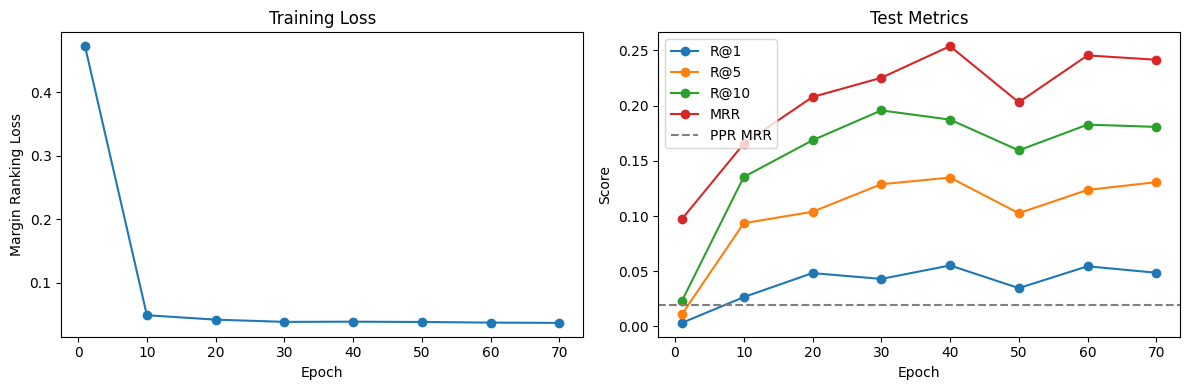

In [55]:
# ── Training Curves ──────────────────────────────────────────────────────
import matplotlib.pyplot as plt

hist_df = pd.DataFrame(history)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(hist_df["epoch"], hist_df["loss"], "o-")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Margin Ranking Loss")
ax1.set_title("Training Loss")

for metric in ["R@1", "R@5", "R@10", "MRR"]:
    ax2.plot(hist_df["epoch"], hist_df[metric], "o-", label=metric)
ax2.axhline(y=0.0193, color="gray", linestyle="--", label="PPR MRR")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Score")
ax2.set_title("Test Metrics")
ax2.legend()

plt.tight_layout()
plt.savefig(DATA_DIR + "training_curves.png", dpi=150)
plt.show()

## Post Training analysis

### 实验1: Ensemble PPR + Model

In [59]:
# ═══ 实验1: Ensemble PPR + Model ═══════════════════════════════════════
model.load_state_dict(torch.load(DATA_DIR + "best_model.pt"))
model.eval()

results_ensemble = []
with torch.no_grad():
    node_embs_eval = model.encode(edge_index, edge_type)
    for disease_idx in tqdm(test_diseases, desc="Ensemble"):
        phenos = list(disease_to_phenotypes.get(disease_idx, []))
        true_drugs = list(test_disease_to_drugs.get(disease_idx, []))
        if not phenos or not true_drugs:
            continue
        all_drugs_t = torch.tensor(drug_indices_arr, dtype=torch.long, device=DEVICE)
        chunk = 512
        model_scores = []
        for c_start in range(0, len(drug_indices_arr), chunk):
            c_end = min(c_start + chunk, len(drug_indices_arr))
            c_drugs = all_drugs_t[c_start:c_end]
            c_phenos = [phenos] * (c_end - c_start)
            c_padded, c_mask = pad_pheno_batch(c_phenos, DEVICE)
            scores = model.score(node_embs_eval, c_drugs, c_padded, c_mask)
            model_scores.append(scores.cpu().numpy())
        model_scores = np.concatenate(model_scores)
        ppr = ppr_scores(phenos, A_norm, alpha=0.15)
        ppr_drug_scores = ppr[drug_indices_arr]
        ms = (model_scores - model_scores.min()) / (model_scores.max() - model_scores.min() + 1e-8)
        ps = (ppr_drug_scores - ppr_drug_scores.min()) / (ppr_drug_scores.max() - ppr_drug_scores.min() + 1e-8)
        for w in [0.9, 0.8, 0.7, 0.6, 0.5]:
            combined = w * ms + (1 - w) * ps
            ranked_order = np.argsort(-combined)
            ranked_drugs = drug_indices_arr[ranked_order].tolist()
            results_ensemble.append({"weight": w, "disease": disease_idx,
                "R@10": recall_at_k(ranked_drugs, true_drugs, 10),
                "R@50": recall_at_k(ranked_drugs, true_drugs, 50),
                "MRR": reciprocal_rank(ranked_drugs, true_drugs)})


ens_df = pd.DataFrame(results_ensemble)
print("═══ Experiment 1: Ensemble ═══")
print(ens_df.groupby("weight")[["MRR", "R@10","R@50"]].mean())

Ensemble: 100%|██████████| 108/108 [01:58<00:00,  1.09s/it]

═══ Experiment 1: Ensemble ═══
             MRR      R@10      R@50
weight                              
0.5     0.145855  0.150027  0.281850
0.6     0.212446  0.174873  0.321910
0.7     0.242715  0.196203  0.339008
0.8     0.263255  0.194673  0.348619
0.9     0.257886  0.186637  0.359667


### Error Analysis on Best Model (base + off-label + ensemble)

In [57]:
# ═══ Error Analysis on Best Model (base + off-label + ensemble) ═══════
model.load_state_dict(torch.load(DATA_DIR + "best_model.pt"))
model.eval()

# 收集每个test disease的详细信息
error_analysis = []
with torch.no_grad():
    node_embs_eval = model.encode(edge_index, edge_type)
    for disease_idx in tqdm(test_diseases, desc="Error analysis"):
        phenos = list(disease_to_phenotypes.get(disease_idx, []))
        true_drugs = list(test_disease_to_drugs.get(disease_idx, []))
        if not phenos or not true_drugs:
            continue

        # Model scores
        all_drugs_t = torch.tensor(drug_indices_arr, dtype=torch.long, device=DEVICE)
        model_scores = []
        for cs in range(0, len(drug_indices_arr), 512):
            ce = min(cs+512, len(drug_indices_arr))
            cp, cm = pad_pheno_batch([phenos]*(ce-cs), DEVICE)
            model_scores.append(model.score(node_embs_eval, all_drugs_t[cs:ce], cp, cm).cpu().numpy())
        model_scores = np.concatenate(model_scores)

        # PPR
        ppr = ppr_scores(phenos, A_norm, alpha=0.15)
        ppr_drug_scores = ppr[drug_indices_arr]

        # Ensemble
        ms = (model_scores - model_scores.min()) / (model_scores.max() - model_scores.min() + 1e-8)
        ps = (ppr_drug_scores - ppr_drug_scores.min()) / (ppr_drug_scores.max() - ppr_drug_scores.min() + 1e-8)
        combined = 0.9 * ms + 0.1 * ps

        ranked_drugs = drug_indices_arr[np.argsort(-combined)].tolist()

        # 找第一个true drug的rank
        true_set = set(true_drugs)
        first_rank = None
        for rank, d in enumerate(ranked_drugs, 1):
            if d in true_set:
                first_rank = rank
                break

        # top-10预测的drug名字
        top10_drugs = ranked_drugs[:10]
        top10_names = []
        for d in top10_drugs:
            name = nodes[nodes["node_index"] == d]["node_name"].values
            is_true = "✓" if d in true_set else ""
            top10_names.append(f"{name[0] if len(name)>0 else d} {is_true}")

        # Disease名字
        d_name = nodes[nodes["node_index"] == disease_idx]["node_name"].values
        d_name = d_name[0] if len(d_name) > 0 else str(disease_idx)

        # Phenotype名字
        pheno_names = []
        for p in phenos[:5]:
            pn = nodes[nodes["node_index"] == p]["node_name"].values
            pheno_names.append(pn[0] if len(pn) > 0 else str(p))

        # true drug有多少在training里见过（作为其他disease的indication）
        true_drugs_in_train = sum(1 for d in true_drugs if drug_degree.get(d, 0) > 0)

        error_analysis.append({
            "disease": disease_idx,
            "disease_name": d_name,
            "n_phenos": len(phenos),
            "n_true_drugs": len(true_drugs),
            "true_drugs_in_train": true_drugs_in_train,
            "first_true_rank": first_rank,
            "mrr": 1.0/first_rank if first_rank else 0,
            "r@10": recall_at_k(ranked_drugs, true_drugs, 10),
            "top10": top10_names,
            "sample_phenos": pheno_names,
        })

ea_df = pd.DataFrame(error_analysis)
ea_df = ea_df.sort_values("mrr", ascending=True)

# ── 最差的case ──
print("=" * 60)
print("WORST 10 CASES (lowest MRR)")
print("=" * 60)
for _, row in ea_df.head(10).iterrows():
    print(f"\n{row['disease_name']} (idx={row['disease']})")
    print(f"  Phenotypes ({row['n_phenos']}): {row['sample_phenos']}")
    print(f"  True drugs: {row['n_true_drugs']}, in train: {row['true_drugs_in_train']}")
    print(f"  First true drug rank: {row['first_true_rank']}")
    print(f"  Top-10 predicted: {row['top10']}")

# ── 最好的case ──
print("\n" + "=" * 60)
print("BEST 10 CASES (highest MRR)")
print("=" * 60)
for _, row in ea_df.tail(10).iterrows():
    print(f"\n{row['disease_name']} (idx={row['disease']})")
    print(f"  Phenotypes ({row['n_phenos']}): {row['sample_phenos']}")
    print(f"  True drugs: {row['n_true_drugs']}, in train: {row['true_drugs_in_train']}")
    print(f"  First true drug rank: {row['first_true_rank']}")
    print(f"  Top-10 predicted: {row['top10']}")

# ── 失败模式分析 ──
print("\n" + "=" * 60)
print("FAILURE PATTERN ANALYSIS")
print("=" * 60)

# 1. MRR vs phenotype count
print("\n── MRR by phenotype count ──")
ea_df["pheno_bin"] = pd.cut(ea_df["n_phenos"], bins=[0,3,10,30,200], labels=["1-3","4-10","11-30","30+"])
print(ea_df.groupby("pheno_bin")[["mrr","r@10"]].agg(["mean","count"]))

# 2. MRR vs true drugs in train
print("\n── MRR by how many true drugs appear in training ──")
ea_df["seen_ratio"] = ea_df["true_drugs_in_train"] / ea_df["n_true_drugs"]
ea_df["seen_bin"] = pd.cut(ea_df["seen_ratio"], bins=[-0.01,0,0.5,1.0], labels=["none","some","all"])
print(ea_df.groupby("seen_bin")[["mrr","r@10"]].agg(["mean","count"]))

# 3. MRR vs n_true_drugs
print("\n── MRR by number of true drugs ──")
ea_df["drug_bin"] = pd.cut(ea_df["n_true_drugs"], bins=[0,1,3,10,100], labels=["1","2-3","4-10","10+"])
print(ea_df.groupby("drug_bin")[["mrr","r@10"]].agg(["mean","count"]))

# 4. 哪些drug总是被排到top但不是正确答案？
print("\n── Most common false positive drugs in top-10 ──")
fp_counter = defaultdict(int)
for _, row in ea_df.iterrows():
    true_set = set(test_disease_to_drugs.get(int(row["disease"]), []))
    for name in row["top10"]:
        if "✓" not in name:
            fp_counter[name.strip()] += 1
fp_sorted = sorted(fp_counter.items(), key=lambda x: -x[1])[:15]
for name, count in fp_sorted:
    print(f"  {count:3d}x  {name}")

ea_df.to_csv(DATA_DIR + "error_analysis.csv", index=False)
print("\nSaved error_analysis.csv")

Error analysis: 100%|██████████| 108/108 [01:58<00:00,  1.10s/it]

WORST 10 CASES (lowest MRR)

essential hypertension, genetic (idx=31523)
  Phenotypes (4): ['Elevated diastolic blood pressure', 'Multifactorial inheritance', 'Elevated mean arterial pressure', 'Elevated systolic blood pressure']
  True drugs: 2, in train: 2
  First true drug rank: 7815
  Top-10 predicted: ['Naloxone ', 'Methadyl acetate ', 'Buprenorphine ', 'Levacetylmethadol ', 'Naltrexone ', 'Acamprosate ', 'Disulfiram ', 'Nalbuphine ', 'Levomethadone ', 'Nalmefene ']

thromboangiitis obliterans (idx=28448)
  Phenotypes (13): ['Sensory neuropathy', 'Acrocyanosis', 'Hyperhidrosis', 'Arterial thrombosis', 'Autosomal recessive inheritance']
  True drugs: 1, in train: 0
  First true drug rank: 7229
  Top-10 predicted: ['Prednisolone ', 'Betamethasone ', 'Methylprednisolone ', 'Prednisone ', 'Dexamethasone ', 'Triamcinolone ', 'Cortisone acetate ', 'Procarbazine ', 'Methoxsalen ', 'Hydrocortisone acetate ']

venous insufficiency (disease) (idx=33602)
  Phenotypes (2): ['Varicose veins', 


/tmp/ipykernel_2944/1772998811.py:110: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(ea_df.groupby("pheno_bin")[["mrr","r@10"]].agg(["mean","count"]))
/tmp/ipykernel_2944/1772998811.py:116: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(ea_df.groupby("seen_bin")[["mrr","r@10"]].agg(["mean","count"]))
/tmp/ipykernel_2944/1772998811.py:121: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(ea_df.groupby("drug

### 实验2: Residual Connection

In [64]:
# ═══ 实验2: Residual Connection ════════════════════════════════════════
import gc
del model
gc.collect()
torch.cuda.empty_cache()

class DrugConditionedCrossAttention2(nn.Module):
    def __init__(self, dim, num_heads=4, dropout=0.1):
        super().__init__()
        self.attn = nn.MultiheadAttention(dim, num_heads, dropout=dropout, batch_first=True)
        self.score_proj = nn.Linear(dim, 1)
    def forward(self, drug_emb, pheno_embs, pheno_mask=None):
        query = drug_emb.unsqueeze(1)
        attn_out, _ = self.attn(query, pheno_embs, pheno_embs, key_padding_mask=pheno_mask)
        return self.score_proj(attn_out.squeeze(1)).squeeze(-1)

class PhenoDrugModelResidual(nn.Module):
    def __init__(self, num_nodes, num_relations, hidden_dim,
                 num_bases=10, num_layers=2, num_heads=4, dropout=0.2):
        super().__init__()
        self.node_emb = nn.Embedding(num_nodes, hidden_dim)
        nn.init.xavier_uniform_(self.node_emb.weight)
        self.convs = nn.ModuleList()
        self.norms = nn.ModuleList()
        for _ in range(num_layers):
            self.convs.append(RGCNConv(hidden_dim, hidden_dim,
                                       num_relations=num_relations, num_bases=num_bases))
            self.norms.append(nn.LayerNorm(hidden_dim))
        self.cross_attn = DrugConditionedCrossAttention2(hidden_dim, num_heads, dropout)
        self.dropout = dropout
    def encode(self, edge_index, edge_type):
        x = self.node_emb.weight
        for conv, norm in zip(self.convs, self.norms):
            residual = x
            x = conv(x, edge_index, edge_type)
            x = norm(x)
            x = F.relu(x)
            x = F.dropout(x, p=self.dropout, training=self.training)
            x = x + residual
        return x
    def score(self, node_embs, drug_indices, pheno_indices_list, pheno_mask):
        drug_emb = node_embs[drug_indices]
        pheno_embs = node_embs[pheno_indices_list]
        return self.cross_attn(drug_emb, pheno_embs, pheno_mask)

torch.manual_seed(42)
np.random.seed(42)
model = PhenoDrugModelResidual(
    num_nodes=NUM_NODES, num_relations=NUM_RELATIONS, hidden_dim=HIDDEN_DIM,
    num_bases=NUM_BASES, num_layers=NUM_LAYERS, num_heads=NUM_HEADS, dropout=DROPOUT,
).to(DEVICE)
print(f"Exp2 params: {sum(p.numel() for p in model.parameters()):,}")

optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=5)
loss_fn = nn.MarginRankingLoss(margin=MARGIN)
best_mrr = 0.0
patience_counter = 0

for epoch in range(1, EPOCHS + 1):
    model.train()
    optimizer.zero_grad()
    perm = np.random.permutation(len(train_samples))
    epoch_loss, n_batches = 0.0, 0
    for start in range(0, len(perm), BATCH_SIZE):
        batch_idx = perm[start:start+BATCH_SIZE]
        pos_drugs, neg_drugs, pheno_padded, pheno_mask = make_batch(train_samples, batch_idx)
        node_embs = model.encode(edge_index, edge_type)
        pos_scores = model.score(node_embs, pos_drugs, pheno_padded, pheno_mask)
        neg_scores = model.score(node_embs, neg_drugs, pheno_padded, pheno_mask)
        target = torch.ones_like(pos_scores)
        loss = loss_fn(pos_scores, neg_scores, target) / ACCUM_STEPS
        loss.backward()
        if (n_batches+1) % ACCUM_STEPS == 0 or (start+BATCH_SIZE) >= len(perm):
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            optimizer.zero_grad()
        epoch_loss += loss.item() * ACCUM_STEPS
        n_batches += 1
    avg_loss = epoch_loss / max(n_batches, 1)
    if epoch % EVAL_EVERY == 0 or epoch == 1:
        model.eval()
        with torch.no_grad():
            node_embs_eval = model.encode(edge_index, edge_type)
            ev = []
            for d in test_diseases:
                ph = list(disease_to_phenotypes.get(d, []))
                td = list(test_disease_to_drugs.get(d, []))
                if not ph or not td: continue
                ad = torch.tensor(drug_indices_arr, dtype=torch.long, device=DEVICE)
                sc = []
                for cs in range(0, len(drug_indices_arr), 512):
                    ce = min(cs+512, len(drug_indices_arr))
                    cp, cm = pad_pheno_batch([ph]*(ce-cs), DEVICE)
                    sc.append(model.score(node_embs_eval, ad[cs:ce], cp, cm).cpu().numpy())
                sc = np.concatenate(sc)
                rd = drug_indices_arr[np.argsort(-sc)].tolist()
                ev.append({"R@10": recall_at_k(rd, td, 10), "MRR": reciprocal_rank(rd, td)})
            rdf = pd.DataFrame(ev)
            mmrr = rdf["MRR"].mean()
            scheduler.step(mmrr)
            print(f"[Exp2] Epoch {epoch:3d} | loss={avg_loss:.4f} | R@10={rdf['R@10'].mean():.4f} MRR={mmrr:.4f}")
            if mmrr > best_mrr:
                best_mrr = mmrr
                patience_counter = 0
                torch.save(model.state_dict(), DATA_DIR + "best_model_residual.pt")
                print(f"  -> New best")
            else:
                patience_counter += EVAL_EVERY
                if patience_counter >= PATIENCE:
                    print(f"  Early stopping"); break
    else:
        print(f"[Exp2] Epoch {epoch:3d} | loss={avg_loss:.4f}")

print(f"\n═══ Experiment 2: Residual ═══")
print(f"Best MRR: {best_mrr:.4f}")

Exp2 params: 36,534,157
[Exp2] Epoch   1 | loss=0.4409 | R@10=0.0258 MRR=0.0818
  -> New best
[Exp2] Epoch   2 | loss=0.2218
[Exp2] Epoch   3 | loss=0.1338
[Exp2] Epoch   4 | loss=0.0937
[Exp2] Epoch   5 | loss=0.0711
[Exp2] Epoch   6 | loss=0.0627
[Exp2] Epoch   7 | loss=0.0531
[Exp2] Epoch   8 | loss=0.0500
[Exp2] Epoch   9 | loss=0.0473
[Exp2] Epoch  10 | loss=0.0467 | R@10=0.1292 MRR=0.1787
  -> New best
[Exp2] Epoch  11 | loss=0.0433
[Exp2] Epoch  12 | loss=0.0434
[Exp2] Epoch  13 | loss=0.0422
[Exp2] Epoch  14 | loss=0.0416
[Exp2] Epoch  15 | loss=0.0429
[Exp2] Epoch  16 | loss=0.0410
[Exp2] Epoch  17 | loss=0.0409
[Exp2] Epoch  18 | loss=0.0406
[Exp2] Epoch  19 | loss=0.0405
[Exp2] Epoch  20 | loss=0.0386 | R@10=0.1552 MRR=0.2189
  -> New best
[Exp2] Epoch  21 | loss=0.0381
[Exp2] Epoch  22 | loss=0.0407
[Exp2] Epoch  23 | loss=0.0385
[Exp2] Epoch  24 | loss=0.0391
[Exp2] Epoch  25 | loss=0.0379
[Exp2] Epoch  26 | loss=0.0395
[Exp2] Epoch  27 | loss=0.0386
[Exp2] Epoch  28 | los

### 实验3: LR=5e-4 + MARGIN=0.5

In [65]:
# ═══ 实验3: LR=5e-4 + MARGIN=0.5 ══════════════════════════════════════
del model
gc.collect()
torch.cuda.empty_cache()

# 用原版model（没有residual）
class DrugConditionedCrossAttention3(nn.Module):
    def __init__(self, dim, num_heads=4, dropout=0.1):
        super().__init__()
        self.attn = nn.MultiheadAttention(dim, num_heads, dropout=dropout, batch_first=True)
        self.score_proj = nn.Linear(dim, 1)
    def forward(self, drug_emb, pheno_embs, pheno_mask=None):
        query = drug_emb.unsqueeze(1)
        attn_out, _ = self.attn(query, pheno_embs, pheno_embs, key_padding_mask=pheno_mask)
        return self.score_proj(attn_out.squeeze(1)).squeeze(-1)

class PhenoDrugModelV3(nn.Module):
    def __init__(self, num_nodes, num_relations, hidden_dim,
                 num_bases=10, num_layers=2, num_heads=4, dropout=0.2):
        super().__init__()
        self.node_emb = nn.Embedding(num_nodes, hidden_dim)
        nn.init.xavier_uniform_(self.node_emb.weight)
        self.convs = nn.ModuleList()
        self.norms = nn.ModuleList()
        for _ in range(num_layers):
            self.convs.append(RGCNConv(hidden_dim, hidden_dim,
                                       num_relations=num_relations, num_bases=num_bases))
            self.norms.append(nn.LayerNorm(hidden_dim))
        self.cross_attn = DrugConditionedCrossAttention3(hidden_dim, num_heads, dropout)
        self.dropout = dropout
    def encode(self, edge_index, edge_type):
        x = self.node_emb.weight
        for conv, norm in zip(self.convs, self.norms):
            x = conv(x, edge_index, edge_type)
            x = norm(x)
            x = F.relu(x)
            x = F.dropout(x, p=self.dropout, training=self.training)
        return x
    def score(self, node_embs, drug_indices, pheno_indices_list, pheno_mask):
        drug_emb = node_embs[drug_indices]
        pheno_embs = node_embs[pheno_indices_list]
        return self.cross_attn(drug_emb, pheno_embs, pheno_mask)

torch.manual_seed(42)
np.random.seed(42)
model = PhenoDrugModelV3(
    num_nodes=NUM_NODES, num_relations=NUM_RELATIONS, hidden_dim=HIDDEN_DIM,
    num_bases=NUM_BASES, num_layers=NUM_LAYERS, num_heads=NUM_HEADS, dropout=DROPOUT,
).to(DEVICE)

EXP3_LR = 5e-4
EXP3_MARGIN = 0.5
EXP3_EPOCHS = 150
EXP3_PATIENCE = 20

optimizer = torch.optim.Adam(model.parameters(), lr=EXP3_LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=5)
loss_fn = nn.MarginRankingLoss(margin=EXP3_MARGIN)
best_mrr = 0.0
patience_counter = 0

for epoch in range(1, EXP3_EPOCHS + 1):
    model.train()
    optimizer.zero_grad()
    perm = np.random.permutation(len(train_samples))
    epoch_loss, n_batches = 0.0, 0
    for start in range(0, len(perm), BATCH_SIZE):
        batch_idx = perm[start:start+BATCH_SIZE]
        pos_drugs, neg_drugs, pheno_padded, pheno_mask = make_batch(train_samples, batch_idx)
        node_embs = model.encode(edge_index, edge_type)
        pos_scores = model.score(node_embs, pos_drugs, pheno_padded, pheno_mask)
        neg_scores = model.score(node_embs, neg_drugs, pheno_padded, pheno_mask)
        target = torch.ones_like(pos_scores)
        loss = loss_fn(pos_scores, neg_scores, target) / ACCUM_STEPS
        loss.backward()
        if (n_batches+1) % ACCUM_STEPS == 0 or (start+BATCH_SIZE) >= len(perm):
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            optimizer.zero_grad()
        epoch_loss += loss.item() * ACCUM_STEPS
        n_batches += 1
    avg_loss = epoch_loss / max(n_batches, 1)
    if epoch % EVAL_EVERY == 0 or epoch == 1:
        model.eval()
        with torch.no_grad():
            node_embs_eval = model.encode(edge_index, edge_type)
            ev = []
            for d in test_diseases:
                ph = list(disease_to_phenotypes.get(d, []))
                td = list(test_disease_to_drugs.get(d, []))
                if not ph or not td: continue
                ad = torch.tensor(drug_indices_arr, dtype=torch.long, device=DEVICE)
                sc = []
                for cs in range(0, len(drug_indices_arr), 512):
                    ce = min(cs+512, len(drug_indices_arr))
                    cp, cm = pad_pheno_batch([ph]*(ce-cs), DEVICE)
                    sc.append(model.score(node_embs_eval, ad[cs:ce], cp, cm).cpu().numpy())
                sc = np.concatenate(sc)
                rd = drug_indices_arr[np.argsort(-sc)].tolist()
                ev.append({"R@10": recall_at_k(rd, td, 10), "MRR": reciprocal_rank(rd, td)})
            rdf = pd.DataFrame(ev)
            mmrr = rdf["MRR"].mean()
            scheduler.step(mmrr)
            print(f"[Exp3] Epoch {epoch:3d} | loss={avg_loss:.4f} | R@10={rdf['R@10'].mean():.4f} MRR={mmrr:.4f}")
            if mmrr > best_mrr:
                best_mrr = mmrr
                patience_counter = 0
                torch.save(model.state_dict(), DATA_DIR + "best_model_lr_margin.pt")
                print(f"  -> New best")
            else:
                patience_counter += EVAL_EVERY
                if patience_counter >= EXP3_PATIENCE:
                    print(f"  Early stopping"); break
    else:
        print(f"[Exp3] Epoch {epoch:3d} | loss={avg_loss:.4f}")

print(f"\n═══ Experiment 3: LR+Margin ═══")
print(f"Best MRR: {best_mrr:.4f}")

[Exp3] Epoch   1 | loss=0.4764 | R@10=0.0195 MRR=0.0696
  -> New best
[Exp3] Epoch   2 | loss=0.2888
[Exp3] Epoch   3 | loss=0.2320
[Exp3] Epoch   4 | loss=0.2081
[Exp3] Epoch   5 | loss=0.1885
[Exp3] Epoch   6 | loss=0.1641
[Exp3] Epoch   7 | loss=0.1407
[Exp3] Epoch   8 | loss=0.1203
[Exp3] Epoch   9 | loss=0.1067
[Exp3] Epoch  10 | loss=0.0951 | R@10=0.0386 MRR=0.0749
  -> New best
[Exp3] Epoch  11 | loss=0.0848
[Exp3] Epoch  12 | loss=0.0796
[Exp3] Epoch  13 | loss=0.0736
[Exp3] Epoch  14 | loss=0.0672
[Exp3] Epoch  15 | loss=0.0642
[Exp3] Epoch  16 | loss=0.0610
[Exp3] Epoch  17 | loss=0.0576
[Exp3] Epoch  18 | loss=0.0583
[Exp3] Epoch  19 | loss=0.0539
[Exp3] Epoch  20 | loss=0.0509 | R@10=0.0448 MRR=0.1027
  -> New best
[Exp3] Epoch  21 | loss=0.0525
[Exp3] Epoch  22 | loss=0.0517
[Exp3] Epoch  23 | loss=0.0505
[Exp3] Epoch  24 | loss=0.0493
[Exp3] Epoch  25 | loss=0.0475
[Exp3] Epoch  26 | loss=0.0492
[Exp3] Epoch  27 | loss=0.0475
[Exp3] Epoch  28 | loss=0.0467
[Exp3] Epoch  2

### 实验4: Contraindication Hard Negatives

In [66]:
# ═══ 实验4: Contraindication Hard Negatives ════════════════════════════
del model
gc.collect()
torch.cuda.empty_cache()

# 建contra_map
contra = kg_train[kg_train["relation"] == "contraindication"]
contra_map = defaultdict(set)
for _, row in contra.iterrows():
    contra_map[int(row["y_index"])].add(int(row["x_index"]))
print(f"Diseases with contraindications: {len(contra_map)}")

# 改negative sampling
def sample_negatives_contra(positive_drug, disease_idx, disease_true_drugs, n=1):
    negs = []
    contras = list(contra_map.get(disease_idx, set()) - disease_true_drugs)
    if contras and np.random.random() < 0.3:  # 只30%概率，比之前50%保守
        chosen = list(np.random.choice(contras, size=min(n, len(contras)), replace=False))
        negs.extend(chosen)
    while len(negs) < n:
        c = np.random.choice(drug_list_sorted, p=drug_weights)
        if c not in disease_true_drugs and c != positive_drug:
            negs.append(c)
    return negs[:n]

def make_batch_contra(samples, batch_indices):
    pos_drugs, neg_drugs, pheno_lists = [], [], []
    for idx in batch_indices:
        d_idx, phenos, pos_drug = samples[idx]
        true_set = train_disease_to_drugs.get(d_idx, set())
        neg = sample_negatives_contra(pos_drug, d_idx, true_set, NEG_RATIO)
        for n in neg:
            pos_drugs.append(pos_drug)
            neg_drugs.append(n)
            pheno_lists.append(phenos)
    pheno_padded, pheno_mask = pad_pheno_batch(pheno_lists, DEVICE)
    pos_drugs_t = torch.tensor(pos_drugs, dtype=torch.long, device=DEVICE)
    neg_drugs_t = torch.tensor(neg_drugs, dtype=torch.long, device=DEVICE)
    return pos_drugs_t, neg_drugs_t, pheno_padded, pheno_mask

# 原版model
class DrugConditionedCrossAttention4(nn.Module):
    def __init__(self, dim, num_heads=4, dropout=0.1):
        super().__init__()
        self.attn = nn.MultiheadAttention(dim, num_heads, dropout=dropout, batch_first=True)
        self.score_proj = nn.Linear(dim, 1)
    def forward(self, drug_emb, pheno_embs, pheno_mask=None):
        query = drug_emb.unsqueeze(1)
        attn_out, _ = self.attn(query, pheno_embs, pheno_embs, key_padding_mask=pheno_mask)
        return self.score_proj(attn_out.squeeze(1)).squeeze(-1)

class PhenoDrugModelV4(nn.Module):
    def __init__(self, num_nodes, num_relations, hidden_dim,
                 num_bases=10, num_layers=2, num_heads=4, dropout=0.2):
        super().__init__()
        self.node_emb = nn.Embedding(num_nodes, hidden_dim)
        nn.init.xavier_uniform_(self.node_emb.weight)
        self.convs = nn.ModuleList()
        self.norms = nn.ModuleList()
        for _ in range(num_layers):
            self.convs.append(RGCNConv(hidden_dim, hidden_dim,
                                       num_relations=num_relations, num_bases=num_bases))
            self.norms.append(nn.LayerNorm(hidden_dim))
        self.cross_attn = DrugConditionedCrossAttention4(hidden_dim, num_heads, dropout)
        self.dropout = dropout
    def encode(self, edge_index, edge_type):
        x = self.node_emb.weight
        for conv, norm in zip(self.convs, self.norms):
            x = conv(x, edge_index, edge_type)
            x = norm(x)
            x = F.relu(x)
            x = F.dropout(x, p=self.dropout, training=self.training)
        return x
    def score(self, node_embs, drug_indices, pheno_indices_list, pheno_mask):
        drug_emb = node_embs[drug_indices]
        pheno_embs = node_embs[pheno_indices_list]
        return self.cross_attn(drug_emb, pheno_embs, pheno_mask)

torch.manual_seed(42)
np.random.seed(42)
model = PhenoDrugModelV4(
    num_nodes=NUM_NODES, num_relations=NUM_RELATIONS, hidden_dim=HIDDEN_DIM,
    num_bases=NUM_BASES, num_layers=NUM_LAYERS, num_heads=NUM_HEADS, dropout=DROPOUT,
).to(DEVICE)

optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=5)
loss_fn = nn.MarginRankingLoss(margin=MARGIN)
best_mrr = 0.0
patience_counter = 0

for epoch in range(1, EPOCHS + 1):
    model.train()
    optimizer.zero_grad()
    perm = np.random.permutation(len(train_samples))
    epoch_loss, n_batches = 0.0, 0
    for start in range(0, len(perm), BATCH_SIZE):
        batch_idx = perm[start:start+BATCH_SIZE]
        pos_drugs, neg_drugs, pheno_padded, pheno_mask = make_batch_contra(train_samples, batch_idx)
        node_embs = model.encode(edge_index, edge_type)
        pos_scores = model.score(node_embs, pos_drugs, pheno_padded, pheno_mask)
        neg_scores = model.score(node_embs, neg_drugs, pheno_padded, pheno_mask)
        target = torch.ones_like(pos_scores)
        loss = loss_fn(pos_scores, neg_scores, target) / ACCUM_STEPS
        loss.backward()
        if (n_batches+1) % ACCUM_STEPS == 0 or (start+BATCH_SIZE) >= len(perm):
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            optimizer.zero_grad()
        epoch_loss += loss.item() * ACCUM_STEPS
        n_batches += 1
    avg_loss = epoch_loss / max(n_batches, 1)
    if epoch % EVAL_EVERY == 0 or epoch == 1:
        model.eval()
        with torch.no_grad():
            node_embs_eval = model.encode(edge_index, edge_type)
            ev = []
            for d in test_diseases:
                ph = list(disease_to_phenotypes.get(d, []))
                td = list(test_disease_to_drugs.get(d, []))
                if not ph or not td: continue
                ad = torch.tensor(drug_indices_arr, dtype=torch.long, device=DEVICE)
                sc = []
                for cs in range(0, len(drug_indices_arr), 512):
                    ce = min(cs+512, len(drug_indices_arr))
                    cp, cm = pad_pheno_batch([ph]*(ce-cs), DEVICE)
                    sc.append(model.score(node_embs_eval, ad[cs:ce], cp, cm).cpu().numpy())
                sc = np.concatenate(sc)
                rd = drug_indices_arr[np.argsort(-sc)].tolist()
                ev.append({"R@10": recall_at_k(rd, td, 10), "MRR": reciprocal_rank(rd, td)})
            rdf = pd.DataFrame(ev)
            mmrr = rdf["MRR"].mean()
            scheduler.step(mmrr)
            print(f"[Exp4] Epoch {epoch:3d} | loss={avg_loss:.4f} | R@10={rdf['R@10'].mean():.4f} MRR={mmrr:.4f}")
            if mmrr > best_mrr:
                best_mrr = mmrr
                patience_counter = 0
                torch.save(model.state_dict(), DATA_DIR + "best_model_contra.pt")
                print(f"  -> New best")
            else:
                patience_counter += EVAL_EVERY
                if patience_counter >= PATIENCE:
                    print(f"  Early stopping"); break
    else:
        print(f"[Exp4] Epoch {epoch:3d} | loss={avg_loss:.4f}")

print(f"\n═══ Experiment 4: Contraindication Negatives (30%) ═══")
print(f"Best MRR: {best_mrr:.4f}")

Diseases with contraindications: 2398
[Exp4] Epoch   1 | loss=0.4803 | R@10=0.0236 MRR=0.0727
  -> New best
[Exp4] Epoch   2 | loss=0.3081
[Exp4] Epoch   3 | loss=0.2411
[Exp4] Epoch   4 | loss=0.2089
[Exp4] Epoch   5 | loss=0.1756
[Exp4] Epoch   6 | loss=0.1580
[Exp4] Epoch   7 | loss=0.1309
[Exp4] Epoch   8 | loss=0.1104
[Exp4] Epoch   9 | loss=0.0965
[Exp4] Epoch  10 | loss=0.0858 | R@10=0.0540 MRR=0.0748
  -> New best
[Exp4] Epoch  11 | loss=0.0789
[Exp4] Epoch  12 | loss=0.0705
[Exp4] Epoch  13 | loss=0.0666
[Exp4] Epoch  14 | loss=0.0596
[Exp4] Epoch  15 | loss=0.0591
[Exp4] Epoch  16 | loss=0.0579
[Exp4] Epoch  17 | loss=0.0560
[Exp4] Epoch  18 | loss=0.0515
[Exp4] Epoch  19 | loss=0.0523
[Exp4] Epoch  20 | loss=0.0493 | R@10=0.0658 MRR=0.1319
  -> New best
[Exp4] Epoch  21 | loss=0.0509
[Exp4] Epoch  22 | loss=0.0490
[Exp4] Epoch  23 | loss=0.0485
[Exp4] Epoch  24 | loss=0.0470
[Exp4] Epoch  25 | loss=0.0463
[Exp4] Epoch  26 | loss=0.0476
[Exp4] Epoch  27 | loss=0.0430
[Exp4] E

### 实验5: NEG_RATIO=3

In [39]:
# ═══ 实验5: NEG_RATIO=3 ════════════════════════════════════════════════
drug_indices_arr = np.array(sorted(drug_indices))
import gc
del model
gc.collect()
torch.cuda.empty_cache()

class DrugConditionedCrossAttention5(nn.Module):
    def __init__(self, dim, num_heads=4, dropout=0.1):
        super().__init__()
        self.attn = nn.MultiheadAttention(dim, num_heads, dropout=dropout, batch_first=True)
        self.score_proj = nn.Linear(dim, 1)
    def forward(self, drug_emb, pheno_embs, pheno_mask=None):
        query = drug_emb.unsqueeze(1)
        attn_out, _ = self.attn(query, pheno_embs, pheno_embs, key_padding_mask=pheno_mask)
        return self.score_proj(attn_out.squeeze(1)).squeeze(-1)

class PhenoDrugModelV5(nn.Module):
    def __init__(self, num_nodes, num_relations, hidden_dim,
                 num_bases=10, num_layers=2, num_heads=4, dropout=0.2):
        super().__init__()
        self.node_emb = nn.Embedding(num_nodes, hidden_dim)
        nn.init.xavier_uniform_(self.node_emb.weight)
        self.convs = nn.ModuleList()
        self.norms = nn.ModuleList()
        for _ in range(num_layers):
            self.convs.append(RGCNConv(hidden_dim, hidden_dim,
                                       num_relations=num_relations, num_bases=num_bases))
            self.norms.append(nn.LayerNorm(hidden_dim))
        self.cross_attn = DrugConditionedCrossAttention5(hidden_dim, num_heads, dropout)
        self.dropout = dropout
    def encode(self, edge_index, edge_type):
        x = self.node_emb.weight
        for conv, norm in zip(self.convs, self.norms):
            x = conv(x, edge_index, edge_type)
            x = norm(x)
            x = F.relu(x)
            x = F.dropout(x, p=self.dropout, training=self.training)
        return x
    def score(self, node_embs, drug_indices, pheno_indices_list, pheno_mask):
        return self.cross_attn(node_embs[drug_indices], node_embs[pheno_indices_list], pheno_mask)

torch.manual_seed(42)
np.random.seed(42)
model = PhenoDrugModelV5(
    num_nodes=NUM_NODES, num_relations=NUM_RELATIONS, hidden_dim=HIDDEN_DIM,
    num_bases=NUM_BASES, num_layers=NUM_LAYERS, num_heads=NUM_HEADS, dropout=DROPOUT,
).to(DEVICE)

EXP5_NEG = 3
EXP5_BS = 256       # 缩小防OOM
EXP5_ACCUM = 8      # 等效batch不变

def make_batch_v5(samples, batch_indices):
    pos_drugs, neg_drugs, pheno_lists = [], [], []
    for idx in batch_indices:
        d_idx, phenos, pos_drug = samples[idx]
        true_set = train_disease_to_drugs.get(d_idx, set())
        neg = sample_negatives(pos_drug, true_set, EXP5_NEG)
        for n in neg:
            pos_drugs.append(pos_drug)
            neg_drugs.append(n)
            pheno_lists.append(phenos)
    pheno_padded, pheno_mask = pad_pheno_batch(pheno_lists, DEVICE)
    return (torch.tensor(pos_drugs, dtype=torch.long, device=DEVICE),
            torch.tensor(neg_drugs, dtype=torch.long, device=DEVICE),
            pheno_padded, pheno_mask)

optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=5)
loss_fn = nn.MarginRankingLoss(margin=MARGIN)
best_mrr = 0.0
patience_counter = 0

for epoch in range(1, EPOCHS + 1):
    model.train()
    optimizer.zero_grad()
    perm = np.random.permutation(len(train_samples))
    epoch_loss, n_batches = 0.0, 0
    for start in range(0, len(perm), EXP5_BS):
        batch_idx = perm[start:start+EXP5_BS]
        pos_drugs, neg_drugs, pheno_padded, pheno_mask = make_batch_v5(train_samples, batch_idx)
        node_embs = model.encode(edge_index, edge_type)
        pos_scores = model.score(node_embs, pos_drugs, pheno_padded, pheno_mask)
        neg_scores = model.score(node_embs, neg_drugs, pheno_padded, pheno_mask)
        loss = loss_fn(pos_scores, neg_scores, torch.ones_like(pos_scores)) / EXP5_ACCUM
        loss.backward()
        if (n_batches+1) % EXP5_ACCUM == 0 or (start+EXP5_BS) >= len(perm):
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            optimizer.zero_grad()
        epoch_loss += loss.item() * EXP5_ACCUM
        n_batches += 1
    avg_loss = epoch_loss / max(n_batches, 1)
    if epoch % EVAL_EVERY == 0 or epoch == 1:
        model.eval()
        with torch.no_grad():
            ne = model.encode(edge_index, edge_type)
            ev = []
            for d in test_diseases:
                ph = list(disease_to_phenotypes.get(d, []))
                td = list(test_disease_to_drugs.get(d, []))
                if not ph or not td: continue
                ad = torch.tensor(drug_indices_arr, dtype=torch.long, device=DEVICE)
                sc = []
                for cs in range(0, len(drug_indices_arr), 512):
                    ce = min(cs+512, len(drug_indices_arr))
                    cp, cm = pad_pheno_batch([ph]*(ce-cs), DEVICE)
                    sc.append(model.score(ne, ad[cs:ce], cp, cm).cpu().numpy())
                sc = np.concatenate(sc)
                rd = drug_indices_arr[np.argsort(-sc)].tolist()
                ev.append({"R@10": recall_at_k(rd, td, 10), "MRR": reciprocal_rank(rd, td)})
            rdf = pd.DataFrame(ev)
            mmrr = rdf["MRR"].mean()
            scheduler.step(mmrr)
            print(f"[Exp5] Epoch {epoch:3d} | loss={avg_loss:.4f} | R@10={rdf['R@10'].mean():.4f} MRR={mmrr:.4f}")
            if mmrr > best_mrr:
                best_mrr = mmrr; patience_counter = 0
                torch.save(model.state_dict(), DATA_DIR + "best_model_neg3.pt")
                print(f"  -> New best")
            else:
                patience_counter += EVAL_EVERY
                if patience_counter >= PATIENCE:
                    print(f"  Early stopping"); break
    else:
        print(f"[Exp5] Epoch {epoch:3d} | loss={avg_loss:.4f}")

print(f"\n═══ Experiment 5: NEG_RATIO=3 ═══")
print(f"Best MRR: {best_mrr:.4f}")

[Exp5] Epoch   1 | loss=0.4933 | R@10=0.0237 MRR=0.0746
  -> New best
[Exp5] Epoch   2 | loss=0.3608
[Exp5] Epoch   3 | loss=0.2815
[Exp5] Epoch   4 | loss=0.2477
[Exp5] Epoch   5 | loss=0.2222
[Exp5] Epoch   6 | loss=0.2083
[Exp5] Epoch   7 | loss=0.1809
[Exp5] Epoch   8 | loss=0.1612
[Exp5] Epoch   9 | loss=0.1489
[Exp5] Epoch  10 | loss=0.1269 | R@10=0.0198 MRR=0.0481
[Exp5] Epoch  11 | loss=0.1212
[Exp5] Epoch  12 | loss=0.1113
[Exp5] Epoch  13 | loss=0.1029
[Exp5] Epoch  14 | loss=0.0952
[Exp5] Epoch  15 | loss=0.0867
[Exp5] Epoch  16 | loss=0.0840
[Exp5] Epoch  17 | loss=0.0837
[Exp5] Epoch  18 | loss=0.0765
[Exp5] Epoch  19 | loss=0.0707
[Exp5] Epoch  20 | loss=0.0670 | R@10=0.0609 MRR=0.1195
  -> New best
[Exp5] Epoch  21 | loss=0.0683
[Exp5] Epoch  22 | loss=0.0663
[Exp5] Epoch  23 | loss=0.0601
[Exp5] Epoch  24 | loss=0.0618
[Exp5] Epoch  25 | loss=0.0588
[Exp5] Epoch  26 | loss=0.0590
[Exp5] Epoch  27 | loss=0.0557
[Exp5] Epoch  28 | loss=0.0528
[Exp5] Epoch  29 | loss=0.053

### 实验6: InfoNCE Loss

In [41]:
# ═══ 实验6: InfoNCE Loss ═══════════════════════════════════════════════
del model
gc.collect()
torch.cuda.empty_cache()

class DrugConditionedCrossAttention6(nn.Module):
    def __init__(self, dim, num_heads=4, dropout=0.1):
        super().__init__()
        self.attn = nn.MultiheadAttention(dim, num_heads, dropout=dropout, batch_first=True)
        self.score_proj = nn.Linear(dim, 1)
    def forward(self, drug_emb, pheno_embs, pheno_mask=None):
        query = drug_emb.unsqueeze(1)
        attn_out, _ = self.attn(query, pheno_embs, pheno_embs, key_padding_mask=pheno_mask)
        return self.score_proj(attn_out.squeeze(1)).squeeze(-1)

class PhenoDrugModelV6(nn.Module):
    def __init__(self, num_nodes, num_relations, hidden_dim,
                 num_bases=10, num_layers=2, num_heads=4, dropout=0.2):
        super().__init__()
        self.node_emb = nn.Embedding(num_nodes, hidden_dim)
        nn.init.xavier_uniform_(self.node_emb.weight)
        self.convs = nn.ModuleList()
        self.norms = nn.ModuleList()
        for _ in range(num_layers):
            self.convs.append(RGCNConv(hidden_dim, hidden_dim,
                                       num_relations=num_relations, num_bases=num_bases))
            self.norms.append(nn.LayerNorm(hidden_dim))
        self.cross_attn = DrugConditionedCrossAttention6(hidden_dim, num_heads, dropout)
        self.dropout = dropout
    def encode(self, edge_index, edge_type):
        x = self.node_emb.weight
        for conv, norm in zip(self.convs, self.norms):
            x = conv(x, edge_index, edge_type)
            x = norm(x)
            x = F.relu(x)
            x = F.dropout(x, p=self.dropout, training=self.training)
        return x
    def score(self, node_embs, drug_indices, pheno_indices_list, pheno_mask):
        return self.cross_attn(node_embs[drug_indices], node_embs[pheno_indices_list], pheno_mask)

torch.manual_seed(42)
np.random.seed(42)
model = PhenoDrugModelV6(
    num_nodes=NUM_NODES, num_relations=NUM_RELATIONS, hidden_dim=HIDDEN_DIM,
    num_bases=NUM_BASES, num_layers=NUM_LAYERS, num_heads=NUM_HEADS, dropout=DROPOUT,
).to(DEVICE)

EXP6_NEG = 5        # 5 negatives per positive for InfoNCE
EXP6_BS = 256
EXP6_ACCUM = 8
EXP6_TEMP = 0.1     # temperature

def make_batch_nce(samples, batch_indices):
    """Returns pos_drugs (B,), neg_drugs (B, num_neg), pheno tensors."""
    all_pos, all_neg, pheno_lists = [], [], []
    for idx in batch_indices:
        d_idx, phenos, pos_drug = samples[idx]
        true_set = train_disease_to_drugs.get(d_idx, set())
        negs = sample_negatives(pos_drug, true_set, EXP5_NEG)
        all_pos.append(pos_drug)
        all_neg.append(negs)
        pheno_lists.append(phenos)
    pheno_padded, pheno_mask = pad_pheno_batch(pheno_lists, DEVICE)
    pos_t = torch.tensor(all_pos, dtype=torch.long, device=DEVICE)
    neg_t = torch.tensor(all_neg, dtype=torch.long, device=DEVICE)  # (B, num_neg)
    return pos_t, neg_t, pheno_padded, pheno_mask

def info_nce_loss(model, node_embs, pos_drugs, neg_drugs, pheno_padded, pheno_mask, temp):
    """
    pos_drugs: (B,)
    neg_drugs: (B, num_neg)
    pheno_padded: (B, max_phenos)
    pheno_mask: (B, max_phenos)
    """
    B, num_neg = neg_drugs.shape

    # Score positive: (B,)
    pos_scores = model.score(node_embs, pos_drugs, pheno_padded, pheno_mask)

    # Score all negatives: need to expand pheno for each negative
    # (B, num_neg) -> (B*num_neg,)
    neg_flat = neg_drugs.reshape(-1)
    pheno_rep = pheno_padded.unsqueeze(1).expand(-1, num_neg, -1).reshape(B*num_neg, -1)
    mask_rep = pheno_mask.unsqueeze(1).expand(-1, num_neg, -1).reshape(B*num_neg, -1)
    neg_scores = model.score(node_embs, neg_flat, pheno_rep, mask_rep)  # (B*num_neg,)
    neg_scores = neg_scores.reshape(B, num_neg)  # (B, num_neg)

    # InfoNCE: softmax over [pos, neg1, neg2, ..., neg_k], label=0
    logits = torch.cat([pos_scores.unsqueeze(1), neg_scores], dim=1) / temp  # (B, 1+num_neg)
    labels = torch.zeros(B, dtype=torch.long, device=logits.device)  # pos is index 0
    return F.cross_entropy(logits, labels)

optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=5)
best_mrr = 0.0
patience_counter = 0

for epoch in range(1, EPOCHS + 1):
    model.train()
    optimizer.zero_grad()
    perm = np.random.permutation(len(train_samples))
    epoch_loss, n_batches = 0.0, 0
    for start in range(0, len(perm), EXP6_BS):
        batch_idx = perm[start:start+EXP6_BS]
        pos_drugs, neg_drugs, pheno_padded, pheno_mask = make_batch_nce(train_samples, batch_idx)
        node_embs = model.encode(edge_index, edge_type)
        loss = info_nce_loss(model, node_embs, pos_drugs, neg_drugs,
                             pheno_padded, pheno_mask, EXP6_TEMP) / EXP6_ACCUM
        loss.backward()
        if (n_batches+1) % EXP6_ACCUM == 0 or (start+EXP6_BS) >= len(perm):
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            optimizer.zero_grad()
        epoch_loss += loss.item() * EXP6_ACCUM
        n_batches += 1
    avg_loss = epoch_loss / max(n_batches, 1)
    if epoch % EVAL_EVERY == 0 or epoch == 1:
        model.eval()
        with torch.no_grad():
            ne = model.encode(edge_index, edge_type)
            ev = []
            for d in test_diseases:
                ph = list(disease_to_phenotypes.get(d, []))
                td = list(test_disease_to_drugs.get(d, []))
                if not ph or not td: continue
                ad = torch.tensor(drug_indices_arr, dtype=torch.long, device=DEVICE)
                sc = []
                for cs in range(0, len(drug_indices_arr), 512):
                    ce = min(cs+512, len(drug_indices_arr))
                    cp, cm = pad_pheno_batch([ph]*(ce-cs), DEVICE)
                    sc.append(model.score(ne, ad[cs:ce], cp, cm).cpu().numpy())
                sc = np.concatenate(sc)
                rd = drug_indices_arr[np.argsort(-sc)].tolist()
                ev.append({"R@10": recall_at_k(rd, td, 10), "MRR": reciprocal_rank(rd, td)})
            rdf = pd.DataFrame(ev)
            mmrr = rdf["MRR"].mean()
            scheduler.step(mmrr)
            print(f"[Exp6] Epoch {epoch:3d} | loss={avg_loss:.4f} | R@10={rdf['R@10'].mean():.4f} MRR={mmrr:.4f}")
            if mmrr > best_mrr:
                best_mrr = mmrr; patience_counter = 0
                torch.save(model.state_dict(), DATA_DIR + "best_model_infonce.pt")
                print(f"  -> New best")
            else:
                patience_counter += EVAL_EVERY
                if patience_counter >= PATIENCE:
                    print(f"  Early stopping"); break
    else:
        print(f"[Exp6] Epoch {epoch:3d} | loss={avg_loss:.4f}")

print(f"\n═══ Experiment 6: InfoNCE Loss (temp={EXP6_TEMP}, neg={EXP6_NEG}) ═══")
print(f"Best MRR: {best_mrr:.4f}")

[Exp6] Epoch   1 | loss=1.6022 | R@10=0.0087 MRR=0.0272
  -> New best
[Exp6] Epoch   2 | loss=1.3662
[Exp6] Epoch   3 | loss=1.1488
[Exp6] Epoch   4 | loss=1.0243
[Exp6] Epoch   5 | loss=0.9299
[Exp6] Epoch   6 | loss=0.8754
[Exp6] Epoch   7 | loss=0.7948
[Exp6] Epoch   8 | loss=0.7435
[Exp6] Epoch   9 | loss=0.6839
[Exp6] Epoch  10 | loss=0.5873 | R@10=0.0318 MRR=0.0704
  -> New best
[Exp6] Epoch  11 | loss=0.5519
[Exp6] Epoch  12 | loss=0.4840
[Exp6] Epoch  13 | loss=0.4278
[Exp6] Epoch  14 | loss=0.3922
[Exp6] Epoch  15 | loss=0.3567
[Exp6] Epoch  16 | loss=0.3305
[Exp6] Epoch  17 | loss=0.3165
[Exp6] Epoch  18 | loss=0.3005
[Exp6] Epoch  19 | loss=0.2813
[Exp6] Epoch  20 | loss=0.2587 | R@10=0.0955 MRR=0.1152
  -> New best
[Exp6] Epoch  21 | loss=0.2460
[Exp6] Epoch  22 | loss=0.2292
[Exp6] Epoch  23 | loss=0.2363
[Exp6] Epoch  24 | loss=0.2186
[Exp6] Epoch  25 | loss=0.2315
[Exp6] Epoch  26 | loss=0.2156
[Exp6] Epoch  27 | loss=0.2173
[Exp6] Epoch  28 | loss=0.2000
[Exp6] Epoch  2

In [65]:
# ═══ Pretrain (balanced speed/quality) ════════════════════════════════
import gc
gc.collect()
torch.cuda.empty_cache()

class PretrainModel(nn.Module):
    def __init__(self, num_nodes, num_relations, hidden_dim, num_bases=10, num_layers=2, dropout=0.2):
        super().__init__()
        self.node_emb = nn.Embedding(num_nodes, hidden_dim)
        nn.init.xavier_uniform_(self.node_emb.weight)
        self.convs = nn.ModuleList()
        self.norms = nn.ModuleList()
        for _ in range(num_layers):
            self.convs.append(RGCNConv(hidden_dim, hidden_dim,
                                       num_relations=num_relations, num_bases=num_bases))
            self.norms.append(nn.LayerNorm(hidden_dim))
        self.dropout = dropout
        self.rel_emb = nn.Embedding(num_relations, hidden_dim)
        nn.init.xavier_uniform_(self.rel_emb.weight)

    def encode(self, edge_index, edge_type):
        x = self.node_emb.weight
        for conv, norm in zip(self.convs, self.norms):
            x = conv(x, edge_index, edge_type)
            x = norm(x)
            x = F.relu(x)
            x = F.dropout(x, p=self.dropout, training=self.training)
        return x

    def decode(self, node_embs, src, dst, rel):
        s = node_embs[src]
        d = node_embs[dst]
        r = self.rel_emb(rel)
        return (s * r * d).sum(dim=-1)

torch.manual_seed(42)
np.random.seed(42)
pretrain_model = PretrainModel(
    NUM_NODES, NUM_RELATIONS, HIDDEN_DIM, NUM_BASES, NUM_LAYERS, DROPOUT
).to(DEVICE)

pt_src = np.concatenate([kg_train["x_index"].values, kg_train["y_index"].values])
pt_dst = np.concatenate([kg_train["y_index"].values, kg_train["x_index"].values])
pt_rel_names = kg_train["relation"].values
pt_rel = np.concatenate([
    np.array([rel2id[r] for r in pt_rel_names]),
    np.array([rel2id[r] + NUM_ORIG_RELS for r in pt_rel_names])
])
print(f"Pretrain edges: {len(pt_src):,}")

PRETRAIN_EPOCHS = 10       # 10就够，不需要30
PRETRAIN_BS = 4096
REENCODE_EVERY = 10        # 每10个batch重新encode

pretrain_optimizer = torch.optim.Adam(pretrain_model.parameters(), lr=1e-3)

for epoch in range(1, PRETRAIN_EPOCHS + 1):
    pretrain_model.train()
    perm = np.random.permutation(len(pt_src))
    epoch_loss, n_batches = 0.0, 0
    node_embs = None

    for start in range(0, len(perm), PRETRAIN_BS):
        # Re-encode every N batches (balances speed vs freshness)
        if n_batches % REENCODE_EVERY == 0:
            node_embs = pretrain_model.encode(edge_index, edge_type).detach()
            node_embs.requires_grad_(True)

        idx = perm[start:start+PRETRAIN_BS]
        src_b = torch.tensor(pt_src[idx], dtype=torch.long, device=DEVICE)
        dst_b = torch.tensor(pt_dst[idx], dtype=torch.long, device=DEVICE)
        rel_b = torch.tensor(pt_rel[idx], dtype=torch.long, device=DEVICE)
        neg_dst = torch.randint(0, NUM_NODES, (len(idx),), device=DEVICE)

        pos_score = pretrain_model.decode(node_embs, src_b, dst_b, rel_b)
        neg_score = pretrain_model.decode(node_embs, src_b, neg_dst, rel_b)

        pos_loss = F.binary_cross_entropy_with_logits(pos_score, torch.ones_like(pos_score))
        neg_loss = F.binary_cross_entropy_with_logits(neg_score, torch.zeros_like(neg_score))
        loss = (pos_loss + neg_loss) / 2

        pretrain_optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(pretrain_model.parameters(), 1.0)
        pretrain_optimizer.step()

        epoch_loss += loss.item()
        n_batches += 1

    print(f"[Pretrain] Epoch {epoch:2d}/{PRETRAIN_EPOCHS} | loss={epoch_loss/n_batches:.4f} | batches={n_batches}")

torch.save(pretrain_model.state_dict(), DATA_DIR + "pretrained_encoder.pt")
print("Pretrained encoder saved.")

Pretrain edges: 16,163,916
[Pretrain] Epoch  1/10 | loss=0.3376 | batches=3947
[Pretrain] Epoch  2/10 | loss=0.3144 | batches=3947
[Pretrain] Epoch  3/10 | loss=0.3138 | batches=3947
[Pretrain] Epoch  4/10 | loss=0.3134 | batches=3947
[Pretrain] Epoch  5/10 | loss=0.3132 | batches=3947
[Pretrain] Epoch  6/10 | loss=0.3133 | batches=3947
[Pretrain] Epoch  7/10 | loss=0.3134 | batches=3947
[Pretrain] Epoch  8/10 | loss=0.3133 | batches=3947
[Pretrain] Epoch  9/10 | loss=0.3128 | batches=3947
[Pretrain] Epoch 10/10 | loss=0.3129 | batches=3947
Pretrained encoder saved.


In [66]:
# ═══ Finetune: load pretrained encoder, fresh cross-attention ═════════
# (跟TxGNN一样：decoder/scorer权重重新初始化)

del pretrain_model
gc.collect()
torch.cuda.empty_cache()

# 5% val split
train_disease_list = sorted(train_diseases)
np.random.seed(42)
np.random.shuffle(train_disease_list)
val_split = int(0.05 * len(train_disease_list))
val_diseases_ft = set(train_disease_list[:val_split])
ft_diseases = set(train_disease_list[val_split:])

val_disease_to_drugs_ft = defaultdict(set)
for _, row in train_pairs.iterrows():
    d = int(row["disease_id"])
    if d in val_diseases_ft:
        val_disease_to_drugs_ft[d].add(int(row["drug_id"]))

ft_samples = []
for d_idx in ft_diseases:
    phenos = list(disease_to_phenotypes.get(d_idx, []))
    drugs  = list(train_disease_to_drugs.get(d_idx, []))
    if not phenos or not drugs:
        continue
    for drug in drugs:
        ft_samples.append((d_idx, phenos, drug))

# Add off-label
offlabel = kg_train[kg_train["relation"] == "off-label use"]
for _, row in offlabel.iterrows():
    d_idx = int(row["y_index"])
    drug  = int(row["x_index"])
    phenos = list(disease_to_phenotypes.get(d_idx, []))
    if phenos and drug in drug_indices and d_idx in ft_diseases:
        ft_samples.append((d_idx, phenos, drug))

print(f"FT train: {len(ft_diseases)} diseases, {len(ft_samples)} samples")
print(f"Val: {len(val_diseases_ft)} diseases")

# Build model, load pretrained encoder weights
model = PhenoDrugModel(
    num_nodes=NUM_NODES, num_relations=NUM_RELATIONS, hidden_dim=HIDDEN_DIM,
    num_bases=NUM_BASES, num_layers=NUM_LAYERS, num_heads=NUM_HEADS, dropout=DROPOUT,
).to(DEVICE)

pretrained = torch.load(DATA_DIR + "pretrained_encoder.pt")
loaded = 0
model_dict = model.state_dict()
for k, v in pretrained.items():
    # 只load encoder部分 (node_emb, convs, norms)，跳过rel_emb (DistMult decoder)
    if k in model_dict and v.shape == model_dict[k].shape and "rel_emb" not in k:
        model_dict[k] = v
        loaded += 1
model.load_state_dict(model_dict)
print(f"Loaded {loaded} pretrained params, cross-attention initialized fresh")

# Finetune with val-based selection
optimizer = torch.optim.Adam(model.parameters(), lr=5e-4, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=5)
loss_fn = nn.MarginRankingLoss(margin=MARGIN)
best_val_mrr = 0.0
patience_counter = 0

for epoch in range(1, 200 + 1):
    model.train()
    optimizer.zero_grad()
    perm = np.random.permutation(len(ft_samples))
    epoch_loss, n_batches = 0.0, 0
    for start in range(0, len(perm), BATCH_SIZE):
        batch_idx = perm[start:start+BATCH_SIZE]
        pos_drugs, neg_drugs, pheno_padded, pheno_mask = make_batch(ft_samples, batch_idx)
        node_embs = model.encode(edge_index, edge_type)
        pos_scores = model.score(node_embs, pos_drugs, pheno_padded, pheno_mask)
        neg_scores = model.score(node_embs, neg_drugs, pheno_padded, pheno_mask)
        loss = loss_fn(pos_scores, neg_scores, torch.ones_like(pos_scores)) / ACCUM_STEPS
        loss.backward()
        if (n_batches+1) % ACCUM_STEPS == 0 or (start+BATCH_SIZE) >= len(perm):
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            optimizer.zero_grad()
        epoch_loss += loss.item() * ACCUM_STEPS
        n_batches += 1
    avg_loss = epoch_loss / max(n_batches, 1)

    # Val-based model selection (every 10 epochs)
    if epoch % 10 == 0 or epoch == 1:
        model.eval()
        with torch.no_grad():
            ne = model.encode(edge_index, edge_type)
            ev = []
            for d in val_diseases_ft:
                ph = list(disease_to_phenotypes.get(d, []))
                td = list(val_disease_to_drugs_ft.get(d, []))
                if not ph or not td: continue
                ad = torch.tensor(drug_indices_arr, dtype=torch.long, device=DEVICE)
                sc = []
                for cs in range(0, len(drug_indices_arr), 512):
                    ce = min(cs+512, len(drug_indices_arr))
                    cp, cm = pad_pheno_batch([ph]*(ce-cs), DEVICE)
                    sc.append(model.score(ne, ad[cs:ce], cp, cm).cpu().numpy())
                sc = np.concatenate(sc)
                rd = drug_indices_arr[np.argsort(-sc)].tolist()
                ev.append({"MRR": reciprocal_rank(rd, td)})
            vdf = pd.DataFrame(ev)
            val_mrr = vdf["MRR"].mean()
            scheduler.step(val_mrr)
            print(f"[FT] Epoch {epoch:3d} | loss={avg_loss:.4f} | val_MRR={val_mrr:.4f}")
            if val_mrr > best_val_mrr:
                best_val_mrr = val_mrr
                patience_counter = 0
                torch.save(model.state_dict(), DATA_DIR + "best_model_finetuned.pt")
                print(f"  -> New best")
            else:
                patience_counter += 10
                if patience_counter >= 30:
                    print(f"  Early stopping"); break
    else:
        print(f"[FT] Epoch {epoch:3d} | loss={avg_loss:.4f}")

# ═══ Final test (only once) ═══════════════════════════════════════════
from sklearn.metrics import roc_auc_score, average_precision_score

model.load_state_dict(torch.load(DATA_DIR + "best_model_finetuned.pt"))
model.eval()
with torch.no_grad():
    ne = model.encode(edge_index, edge_type)
    test_ev = []
    for d in tqdm(test_diseases, desc="Final test"):
        ph = list(disease_to_phenotypes.get(d, []))
        td = list(test_disease_to_drugs.get(d, []))
        if not ph or not td: continue
        ad = torch.tensor(drug_indices_arr, dtype=torch.long, device=DEVICE)
        sc = []
        for cs in range(0, len(drug_indices_arr), 512):
            ce = min(cs+512, len(drug_indices_arr))
            cp, cm = pad_pheno_batch([ph]*(ce-cs), DEVICE)
            sc.append(model.score(ne, ad[cs:ce], cp, cm).cpu().numpy())
        sc = np.concatenate(sc)
        rd = drug_indices_arr[np.argsort(-sc)].tolist()
        labels = np.array([1 if x in set(td) else 0 for x in drug_indices_arr])
        test_ev.append({
            "MRR": reciprocal_rank(rd, td), "R@10": recall_at_k(rd, td, 10),
            "R@50": recall_at_k(rd, td, 50),
            "AUROC": roc_auc_score(labels, sc) if 0 < labels.sum() < len(labels) else None,
            "AUPRC": average_precision_score(labels, sc) if labels.sum() > 0 else None,
        })
tdf = pd.DataFrame(test_ev)
print("\n" + "=" * 60)
print("PRETRAIN + FINETUNE (val-based selection)")
print("=" * 60)
for m in ["MRR", "R@10", "R@50", "AUROC", "AUPRC"]:
    print(f"  {m:<8s}: {tdf[m].dropna().mean():.4f}")
print(f"\nPrevious best (no pretrain): MRR=0.25")

FT train: 410 diseases, 3224 samples
Val: 21 diseases
Loaded 19 pretrained params, cross-attention initialized fresh
[FT] Epoch   1 | loss=0.4696 | val_MRR=0.0991
  -> New best
[FT] Epoch   2 | loss=0.2596
[FT] Epoch   3 | loss=0.1703
[FT] Epoch   4 | loss=0.1142
[FT] Epoch   5 | loss=0.0898
[FT] Epoch   6 | loss=0.0706
[FT] Epoch   7 | loss=0.0638
[FT] Epoch   8 | loss=0.0603
[FT] Epoch   9 | loss=0.0541
[FT] Epoch  10 | loss=0.0500 | val_MRR=0.1677
  -> New best
[FT] Epoch  11 | loss=0.0531
[FT] Epoch  12 | loss=0.0507
[FT] Epoch  13 | loss=0.0514
[FT] Epoch  14 | loss=0.0469
[FT] Epoch  15 | loss=0.0454
[FT] Epoch  16 | loss=0.0434
[FT] Epoch  17 | loss=0.0455
[FT] Epoch  18 | loss=0.0420
[FT] Epoch  19 | loss=0.0443
[FT] Epoch  20 | loss=0.0425 | val_MRR=0.2150
  -> New best
[FT] Epoch  21 | loss=0.0441
[FT] Epoch  22 | loss=0.0444
[FT] Epoch  23 | loss=0.0395
[FT] Epoch  24 | loss=0.0407
[FT] Epoch  25 | loss=0.0421
[FT] Epoch  26 | loss=0.0414
[FT] Epoch  27 | loss=0.0416
[FT] Ep

Final test: 100%|██████████| 108/108 [00:38<00:00,  2.78it/s]


PRETRAIN + FINETUNE (val-based selection)
  MRR     : 0.1877
  R@10    : 0.1248
  R@50    : 0.3576
  AUROC   : 0.8453
  AUPRC   : 0.1330

Previous best (no pretrain): MRR=0.25


In [21]:
drug_indices_arr = np.array(sorted(drug_indices))
# ═══ Complete Training with 10% Val Split ═════════════════════════════
import gc
del model
gc.collect()
torch.cuda.empty_cache()

# ── 10% val split ──
train_disease_list = sorted(train_diseases)
np.random.seed(42)
np.random.shuffle(train_disease_list)
val_split = int(0.1 * len(train_disease_list))
val_diseases_ft = set(train_disease_list[:val_split])
ft_diseases = set(train_disease_list[val_split:])

# Val ground truth
val_disease_to_drugs_ft = defaultdict(set)
for _, row in train_pairs.iterrows():
    d = int(row["disease_id"])
    if d in val_diseases_ft:
        val_disease_to_drugs_ft[d].add(int(row["drug_id"]))

# Off-label for val too
offlabel_all = kg[kg["relation"] == "off-label use"]
for _, row in offlabel_all.iterrows():
    d = int(row["y_index"])
    drug = int(row["x_index"])
    if d in val_diseases_ft and drug in drug_indices:
        val_disease_to_drugs_ft[d].add(drug)

# Train samples (only ft_diseases)
ft_samples = []
for d_idx in ft_diseases:
    phenos = list(disease_to_phenotypes.get(d_idx, []))
    drugs  = list(train_disease_to_drugs.get(d_idx, []))
    if not phenos or not drugs:
        continue
    for drug in drugs:
        ft_samples.append((d_idx, phenos, drug))

# Add off-label
offlabel_train = kg_train[kg_train["relation"] == "off-label use"]
for _, row in offlabel_train.iterrows():
    d_idx = int(row["y_index"])
    drug  = int(row["x_index"])
    phenos = list(disease_to_phenotypes.get(d_idx, []))
    if phenos and drug in drug_indices and d_idx in ft_diseases:
        ft_samples.append((d_idx, phenos, drug))

print(f"Train diseases: {len(ft_diseases)}")
print(f"Val diseases: {len(val_diseases_ft)}")
print(f"Val pairs: {sum(len(v) for v in val_disease_to_drugs_ft.values())}")
print(f"Train samples: {len(ft_samples)}")

# ── Original model ──
class DrugConditionedCrossAttentionFinal(nn.Module):
    def __init__(self, dim, num_heads=4, dropout=0.1):
        super().__init__()
        self.attn = nn.MultiheadAttention(dim, num_heads, dropout=dropout, batch_first=True)
        self.score_proj = nn.Linear(dim, 1)
    def forward(self, drug_emb, pheno_embs, pheno_mask=None):
        query = drug_emb.unsqueeze(1)
        attn_out, _ = self.attn(query, pheno_embs, pheno_embs, key_padding_mask=pheno_mask)
        return self.score_proj(attn_out.squeeze(1)).squeeze(-1)

class PhenoDrugModelFinal(nn.Module):
    def __init__(self, num_nodes, num_relations, hidden_dim,
                 num_bases=10, num_layers=2, num_heads=4, dropout=0.2):
        super().__init__()
        self.node_emb = nn.Embedding(num_nodes, hidden_dim)
        nn.init.xavier_uniform_(self.node_emb.weight)
        self.convs = nn.ModuleList()
        self.norms = nn.ModuleList()
        for _ in range(num_layers):
            self.convs.append(RGCNConv(hidden_dim, hidden_dim,
                                       num_relations=num_relations, num_bases=num_bases))
            self.norms.append(nn.LayerNorm(hidden_dim))
        self.cross_attn = DrugConditionedCrossAttentionFinal(hidden_dim, num_heads, dropout)
        self.dropout = dropout
    def encode(self, edge_index, edge_type):
        x = self.node_emb.weight
        for conv, norm in zip(self.convs, self.norms):
            x = conv(x, edge_index, edge_type)
            x = norm(x)
            x = F.relu(x)
            x = F.dropout(x, p=self.dropout, training=self.training)
        return x
    def score(self, node_embs, drug_indices, pheno_indices_list, pheno_mask):
        return self.cross_attn(node_embs[drug_indices], node_embs[pheno_indices_list], pheno_mask)

torch.manual_seed(42)
np.random.seed(42)
model = PhenoDrugModelFinal(
    num_nodes=NUM_NODES, num_relations=NUM_RELATIONS, hidden_dim=HIDDEN_DIM,
    num_bases=NUM_BASES, num_layers=NUM_LAYERS, num_heads=NUM_HEADS, dropout=DROPOUT,
).to(DEVICE)
print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")

# ── Training with val-based selection ──
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=5)
loss_fn = nn.MarginRankingLoss(margin=1.0)
best_val_mrr = 0.0
patience_counter = 0
history = []

for epoch in range(1, 150 + 1):
    model.train()
    optimizer.zero_grad()
    perm = np.random.permutation(len(ft_samples))
    epoch_loss, n_batches = 0.0, 0
    for start in range(0, len(perm), BATCH_SIZE):
        batch_idx = perm[start:start+BATCH_SIZE]
        pos_drugs, neg_drugs, pheno_padded, pheno_mask = make_batch(ft_samples, batch_idx)
        node_embs = model.encode(edge_index, edge_type)
        pos_scores = model.score(node_embs, pos_drugs, pheno_padded, pheno_mask)
        neg_scores = model.score(node_embs, neg_drugs, pheno_padded, pheno_mask)
        loss = loss_fn(pos_scores, neg_scores, torch.ones_like(pos_scores)) / ACCUM_STEPS
        loss.backward()
        if (n_batches+1) % ACCUM_STEPS == 0 or (start+BATCH_SIZE) >= len(perm):
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            optimizer.zero_grad()
        epoch_loss += loss.item() * ACCUM_STEPS
        n_batches += 1
    avg_loss = epoch_loss / max(n_batches, 1)

    # ── Val eval every 5 epochs ──
    if epoch % 5 == 0 or epoch == 1:
        model.eval()
        with torch.no_grad():
            ne = model.encode(edge_index, edge_type)
            val_ev = []
            for d in val_diseases_ft:
                ph = list(disease_to_phenotypes.get(d, []))
                td = list(val_disease_to_drugs_ft.get(d, []))
                if not ph or not td: continue
                ad = torch.tensor(drug_indices_arr, dtype=torch.long, device=DEVICE)
                sc = []
                for cs in range(0, len(drug_indices_arr), 512):
                    ce = min(cs+512, len(drug_indices_arr))
                    cp, cm = pad_pheno_batch([ph]*(ce-cs), DEVICE)
                    sc.append(model.score(ne, ad[cs:ce], cp, cm).cpu().numpy())
                sc = np.concatenate(sc)
                rd = drug_indices_arr[np.argsort(-sc)].tolist()
                val_ev.append({"MRR": reciprocal_rank(rd, td), "R@10": recall_at_k(rd, td, 10)})
            vdf = pd.DataFrame(val_ev)
            val_mrr = vdf["MRR"].mean()
            scheduler.step(val_mrr)
            print(f"Epoch {epoch:3d} | loss={avg_loss:.4f} | val_MRR={val_mrr:.4f}  val_R@10={vdf['R@10'].mean():.4f}")
            history.append({"epoch": epoch, "loss": avg_loss, "val_MRR": val_mrr})
            if val_mrr > best_val_mrr:
                best_val_mrr = val_mrr
                patience_counter = 0
                torch.save(model.state_dict(), DATA_DIR + "best_model_valsplit.pt")
                print(f"  -> New best val MRR")
            else:
                patience_counter += 5
                if patience_counter >= 25:
                    print(f"  Early stopping at epoch {epoch}")
                    break
    else:
        print(f"Epoch {epoch:3d} | loss={avg_loss:.4f}")

# ═══ Final test eval (ONLY ONCE) ═════════════════════════════════════
from sklearn.metrics import roc_auc_score, average_precision_score

model.load_state_dict(torch.load(DATA_DIR + "best_model_valsplit.pt"))
model.eval()
with torch.no_grad():
    ne = model.encode(edge_index, edge_type)
    test_ev = []
    for d in tqdm(test_diseases, desc="Final test"):
        ph = list(disease_to_phenotypes.get(d, []))
        td = list(test_disease_to_drugs.get(d, []))
        if not ph or not td: continue
        ad = torch.tensor(drug_indices_arr, dtype=torch.long, device=DEVICE)
        sc = []
        for cs in range(0, len(drug_indices_arr), 512):
            ce = min(cs+512, len(drug_indices_arr))
            cp, cm = pad_pheno_batch([ph]*(ce-cs), DEVICE)
            sc.append(model.score(ne, ad[cs:ce], cp, cm).cpu().numpy())
        sc = np.concatenate(sc)
        rd = drug_indices_arr[np.argsort(-sc)].tolist()
        labels = np.array([1 if x in set(td) else 0 for x in drug_indices_arr])
        test_ev.append({
            "MRR": reciprocal_rank(rd, td),
            "R@10": recall_at_k(rd, td, 10),
            "R@50": recall_at_k(rd, td, 50),
            "AUROC": roc_auc_score(labels, sc) if 0 < labels.sum() < len(labels) else None,
            "AUPRC": average_precision_score(labels, sc) if labels.sum() > 0 else None,
        })
tdf = pd.DataFrame(test_ev)
print("\n" + "=" * 60)
print("VAL-BASED SELECTION — Test Results (reported once)")
print("=" * 60)
for m in ["MRR", "R@10", "R@50", "AUROC", "AUPRC"]:
    print(f"  {m:<8s}: {tdf[m].dropna().mean():.4f}")
print(f"\nBest val MRR during training: {best_val_mrr:.4f}")

Train diseases: 388
Val diseases: 43
Val pairs: 252
Train samples: 3069
Parameters: 36,534,157
Epoch   1 | loss=0.9879 | val_MRR=0.0267  val_R@10=0.0161
  -> New best val MRR
Epoch   2 | loss=0.6540
Epoch   3 | loss=0.5299
Epoch   4 | loss=0.4859
Epoch   5 | loss=0.4410 | val_MRR=0.0295  val_R@10=0.0149
  -> New best val MRR
Epoch   6 | loss=0.3942
Epoch   7 | loss=0.3358
Epoch   8 | loss=0.2856
Epoch   9 | loss=0.2679
Epoch  10 | loss=0.2200 | val_MRR=0.0573  val_R@10=0.0585
  -> New best val MRR
Epoch  11 | loss=0.2029
Epoch  12 | loss=0.1814
Epoch  13 | loss=0.1581
Epoch  14 | loss=0.1562
Epoch  15 | loss=0.1376 | val_MRR=0.0437  val_R@10=0.0212
Epoch  16 | loss=0.1311
Epoch  17 | loss=0.1221
Epoch  18 | loss=0.1200
Epoch  19 | loss=0.1153
Epoch  20 | loss=0.1131 | val_MRR=0.0729  val_R@10=0.0615
  -> New best val MRR
Epoch  21 | loss=0.1019
Epoch  22 | loss=0.1036
Epoch  23 | loss=0.0998
Epoch  24 | loss=0.1004
Epoch  25 | loss=0.0917 | val_MRR=0.1069  val_R@10=0.1056
  -> New best

Final test: 100%|██████████| 108/108 [00:38<00:00,  2.79it/s]


VAL-BASED SELECTION — Test Results (reported once)
  MRR     : 0.1408
  R@10    : 0.0848
  R@50    : 0.2314
  AUROC   : 0.8699
  AUPRC   : 0.0969

Best val MRR during training: 0.2308


In [23]:
# ═══ TxGNN-style Balanced AUPRC ══════════════════════════════════════
from sklearn.metrics import average_precision_score, roc_auc_score

model.load_state_dict(torch.load(DATA_DIR + "best_model.pt"))
model.eval()

all_labels = []
all_scores = []

np.random.seed(42)
drug_indices_set = set(drug_indices_arr.tolist())

with torch.no_grad():
    ne = model.encode(edge_index, edge_type)
    for d in tqdm(test_diseases, desc="Balanced AUPRC"):
        ph = list(disease_to_phenotypes.get(d, []))
        td = set(test_disease_to_drugs.get(d, []))
        if not ph or not td: continue

        # Positive drugs
        pos_drugs = list(td)

        # Sample equal number of negative drugs (1:1 balanced)
        neg_candidates = [x for x in drug_indices_arr if x not in td]
        neg_drugs = list(np.random.choice(neg_candidates, size=len(pos_drugs), replace=False))

        # Score both
        eval_drugs = pos_drugs + neg_drugs
        eval_labels = [1] * len(pos_drugs) + [0] * len(neg_drugs)

        eval_t = torch.tensor(eval_drugs, dtype=torch.long, device=DEVICE)
        cp, cm = pad_pheno_batch([ph] * len(eval_drugs), DEVICE)
        scores = model.score(ne, eval_t, cp, cm).cpu().numpy()

        all_labels.extend(eval_labels)
        all_scores.extend(scores.tolist())

balanced_auprc = average_precision_score(all_labels, all_scores)
balanced_auroc = roc_auc_score(all_labels, all_scores)

print(f"Balanced AUPRC (TxGNN-style): {balanced_auprc:.4f}")
print(f"Balanced AUROC (TxGNN-style): {balanced_auroc:.4f}")
print(f"\nTxGNN paper reports: AUPRC ~0.87-0.91")

Balanced AUPRC: 100%|██████████| 108/108 [00:00<00:00, 261.16it/s]

Balanced AUPRC (TxGNN-style): 0.5942
Balanced AUROC (TxGNN-style): 0.6534

TxGNN paper reports: AUPRC ~0.87-0.91


In [24]:
# ═══════════════════════════════════════════════════════════════════════
# COMPLETE PIPELINE: E2E Pretrain + Finetune + Proper Eval
# ═══════════════════════════════════════════════════════════════════════
import gc, torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import pandas as pd
from collections import defaultdict
from tqdm import tqdm
from torch_geometric.nn import RGCNConv
from sklearn.metrics import roc_auc_score, average_precision_score

gc.collect()
torch.cuda.empty_cache()

drug_indices_arr = np.array(sorted(drug_indices))

# ═══ PART 1: END-TO-END PRETRAIN ═════════════════════════════════════

class PretrainModelE2E(nn.Module):
    def __init__(self, num_nodes, num_relations, hidden_dim, num_bases=10, num_layers=2, dropout=0.2):
        super().__init__()
        self.node_emb = nn.Embedding(num_nodes, hidden_dim)
        nn.init.xavier_uniform_(self.node_emb.weight)
        self.convs = nn.ModuleList()
        self.norms = nn.ModuleList()
        for _ in range(num_layers):
            self.convs.append(RGCNConv(hidden_dim, hidden_dim,
                                       num_relations=num_relations, num_bases=num_bases))
            self.norms.append(nn.LayerNorm(hidden_dim))
        self.dropout = dropout
        self.rel_emb = nn.Embedding(num_relations, hidden_dim)
        nn.init.xavier_uniform_(self.rel_emb.weight)

    def encode(self, edge_index, edge_type):
        x = self.node_emb.weight
        for conv, norm in zip(self.convs, self.norms):
            x = conv(x, edge_index, edge_type)
            x = norm(x)
            x = F.relu(x)
            x = F.dropout(x, p=self.dropout, training=self.training)
        return x

    def decode(self, node_embs, src, dst, rel):
        return (node_embs[src] * self.rel_emb(rel) * node_embs[dst]).sum(dim=-1)

torch.manual_seed(42)
np.random.seed(42)
pretrain_model = PretrainModelE2E(
    NUM_NODES, NUM_RELATIONS, HIDDEN_DIM, NUM_BASES, NUM_LAYERS, DROPOUT
).to(DEVICE)

pt_src = np.concatenate([kg_train["x_index"].values, kg_train["y_index"].values])
pt_dst = np.concatenate([kg_train["y_index"].values, kg_train["x_index"].values])
pt_rel_names = kg_train["relation"].values
pt_rel = np.concatenate([
    np.array([rel2id[r] for r in pt_rel_names]),
    np.array([rel2id[r] + NUM_ORIG_RELS for r in pt_rel_names])
])
print(f"Pretrain edges: {len(pt_src):,}")
print(f"Pretrain params: {sum(p.numel() for p in pretrain_model.parameters()):,}")

PRETRAIN_EPOCHS = 10
DECODE_BS = 8192
DECODES_PER_STEP = 4
pretrain_optimizer = torch.optim.Adam(pretrain_model.parameters(), lr=1e-3)

import time
pretrain_start = time.time()

for epoch in range(1, PRETRAIN_EPOCHS + 1):
    epoch_start = time.time()
    pretrain_model.train()
    perm = np.random.permutation(len(pt_src))
    epoch_loss, n_steps = 0.0, 0
    ptr = 0
    total_steps = len(perm) // (DECODE_BS * DECODES_PER_STEP) + 1

    while ptr < len(perm):
        node_embs = pretrain_model.encode(edge_index, edge_type)
        total_loss = torch.tensor(0.0, device=DEVICE)

        for _ in range(DECODES_PER_STEP):
            if ptr >= len(perm):
                break
            idx = perm[ptr:ptr+DECODE_BS]
            ptr += DECODE_BS

            src_b = torch.tensor(pt_src[idx], dtype=torch.long, device=DEVICE)
            dst_b = torch.tensor(pt_dst[idx], dtype=torch.long, device=DEVICE)
            rel_b = torch.tensor(pt_rel[idx], dtype=torch.long, device=DEVICE)
            neg_dst = torch.randint(0, NUM_NODES, (len(idx),), device=DEVICE)

            pos_score = pretrain_model.decode(node_embs, src_b, dst_b, rel_b)
            neg_score = pretrain_model.decode(node_embs, src_b, neg_dst, rel_b)

            pos_loss = F.binary_cross_entropy_with_logits(pos_score, torch.ones_like(pos_score))
            neg_loss = F.binary_cross_entropy_with_logits(neg_score, torch.zeros_like(neg_score))
            total_loss = total_loss + (pos_loss + neg_loss) / 2

        total_loss = total_loss / DECODES_PER_STEP
        pretrain_optimizer.zero_grad()
        total_loss.backward()
        torch.nn.utils.clip_grad_norm_(pretrain_model.parameters(), 1.0)
        pretrain_optimizer.step()

        epoch_loss += total_loss.item()
        n_steps += 1

        if n_steps % 50 == 0:
            elapsed = time.time() - epoch_start
            eta_epoch = elapsed / n_steps * (total_steps - n_steps)
            print(f"  [Pretrain] Epoch {epoch:2d} | step {n_steps}/{total_steps} | "
                  f"loss={total_loss.item():.4f} | edges={ptr:,}/{len(perm):,} | "
                  f"elapsed={elapsed:.0f}s | ETA={eta_epoch:.0f}s")

    epoch_time = time.time() - epoch_start
    total_elapsed = time.time() - pretrain_start
    eta_total = total_elapsed / epoch * (PRETRAIN_EPOCHS - epoch)
    print(f"[Pretrain] Epoch {epoch:2d}/{PRETRAIN_EPOCHS} | avg_loss={epoch_loss/n_steps:.4f} | "
          f"steps={n_steps} | time={epoch_time:.0f}s | total={total_elapsed:.0f}s | ETA={eta_total:.0f}s")

torch.save(pretrain_model.state_dict(), DATA_DIR + "pretrained_e2e.pt")
print(f"\nPretrained encoder saved. Total pretrain time: {time.time()-pretrain_start:.0f}s\n")


# ═══ PART 2: FINETUNE WITH VAL-BASED SELECTION ═══════════════════════

del pretrain_model
gc.collect()
torch.cuda.empty_cache()

# ── 10% val split ──
train_disease_list = sorted(train_diseases)
np.random.seed(42)
np.random.shuffle(train_disease_list)
val_split = int(0.1 * len(train_disease_list))
val_diseases_ft = set(train_disease_list[:val_split])
ft_diseases = set(train_disease_list[val_split:])

# Val ground truth (indication + off-label)
val_disease_to_drugs_ft = defaultdict(set)
for _, row in train_pairs.iterrows():
    d = int(row["disease_id"])
    if d in val_diseases_ft:
        val_disease_to_drugs_ft[d].add(int(row["drug_id"]))
offlabel_all = kg[kg["relation"] == "off-label use"]
for _, row in offlabel_all.iterrows():
    d = int(row["y_index"])
    drug = int(row["x_index"])
    if d in val_diseases_ft and drug in drug_indices:
        val_disease_to_drugs_ft[d].add(drug)

# Train samples (indication + off-label, only ft_diseases)
ft_samples = []
for d_idx in ft_diseases:
    phenos = list(disease_to_phenotypes.get(d_idx, []))
    drugs = list(train_disease_to_drugs.get(d_idx, []))
    if not phenos or not drugs:
        continue
    for drug in drugs:
        ft_samples.append((d_idx, phenos, drug))

offlabel_train = kg_train[kg_train["relation"] == "off-label use"]
for _, row in offlabel_train.iterrows():
    d_idx = int(row["y_index"])
    drug = int(row["x_index"])
    phenos = list(disease_to_phenotypes.get(d_idx, []))
    if phenos and drug in drug_indices and d_idx in ft_diseases:
        ft_samples.append((d_idx, phenos, drug))

print(f"Train: {len(ft_diseases)} diseases, {len(ft_samples)} samples")
print(f"Val: {len(val_diseases_ft)} diseases, {sum(len(v) for v in val_disease_to_drugs_ft.values())} pairs")

# ── Model (original architecture) ──
class DrugConditionedCrossAttentionPipe(nn.Module):
    def __init__(self, dim, num_heads=4, dropout=0.1):
        super().__init__()
        self.attn = nn.MultiheadAttention(dim, num_heads, dropout=dropout, batch_first=True)
        self.score_proj = nn.Linear(dim, 1)
    def forward(self, drug_emb, pheno_embs, pheno_mask=None):
        query = drug_emb.unsqueeze(1)
        attn_out, _ = self.attn(query, pheno_embs, pheno_embs, key_padding_mask=pheno_mask)
        return self.score_proj(attn_out.squeeze(1)).squeeze(-1)

class PhenoDrugModelPipe(nn.Module):
    def __init__(self, num_nodes, num_relations, hidden_dim,
                 num_bases=10, num_layers=2, num_heads=4, dropout=0.2):
        super().__init__()
        self.node_emb = nn.Embedding(num_nodes, hidden_dim)
        nn.init.xavier_uniform_(self.node_emb.weight)
        self.convs = nn.ModuleList()
        self.norms = nn.ModuleList()
        for _ in range(num_layers):
            self.convs.append(RGCNConv(hidden_dim, hidden_dim,
                                       num_relations=num_relations, num_bases=num_bases))
            self.norms.append(nn.LayerNorm(hidden_dim))
        self.cross_attn = DrugConditionedCrossAttentionPipe(hidden_dim, num_heads, dropout)
        self.dropout = dropout
    def encode(self, edge_index, edge_type):
        x = self.node_emb.weight
        for conv, norm in zip(self.convs, self.norms):
            x = conv(x, edge_index, edge_type)
            x = norm(x)
            x = F.relu(x)
            x = F.dropout(x, p=self.dropout, training=self.training)
        return x
    def score(self, node_embs, drug_indices, pheno_indices_list, pheno_mask):
        return self.cross_attn(node_embs[drug_indices], node_embs[pheno_indices_list], pheno_mask)

torch.manual_seed(42)
np.random.seed(42)
model = PhenoDrugModelPipe(
    num_nodes=NUM_NODES, num_relations=NUM_RELATIONS, hidden_dim=HIDDEN_DIM,
    num_bases=NUM_BASES, num_layers=NUM_LAYERS, num_heads=NUM_HEADS, dropout=DROPOUT,
).to(DEVICE)

# Load pretrained encoder (skip rel_emb = DistMult decoder)
pretrained = torch.load(DATA_DIR + "pretrained_e2e.pt")
model_dict = model.state_dict()
loaded = 0
for k, v in pretrained.items():
    if k in model_dict and v.shape == model_dict[k].shape and "rel_emb" not in k:
        model_dict[k] = v
        loaded += 1
model.load_state_dict(model_dict)
print(f"Loaded {loaded} pretrained params, cross-attention fresh")

# ── Finetune (original hyperparams) ──
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=5)
loss_fn = nn.MarginRankingLoss(margin=1.0)
best_val_mrr = 0.0
patience_counter = 0
ft_start = time.time()

for epoch in range(1, 150 + 1):
    model.train()
    optimizer.zero_grad()
    perm = np.random.permutation(len(ft_samples))
    epoch_loss, n_batches = 0.0, 0
    for start in range(0, len(perm), BATCH_SIZE):
        batch_idx = perm[start:start+BATCH_SIZE]
        pos_drugs, neg_drugs, pheno_padded, pheno_mask = make_batch(ft_samples, batch_idx)
        node_embs = model.encode(edge_index, edge_type)
        pos_scores = model.score(node_embs, pos_drugs, pheno_padded, pheno_mask)
        neg_scores = model.score(node_embs, neg_drugs, pheno_padded, pheno_mask)
        loss = loss_fn(pos_scores, neg_scores, torch.ones_like(pos_scores)) / ACCUM_STEPS
        loss.backward()
        if (n_batches+1) % ACCUM_STEPS == 0 or (start+BATCH_SIZE) >= len(perm):
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            optimizer.zero_grad()
        epoch_loss += loss.item() * ACCUM_STEPS
        n_batches += 1
    avg_loss = epoch_loss / max(n_batches, 1)

    if epoch % 5 == 0 or epoch == 1:
        model.eval()
        with torch.no_grad():
            ne = model.encode(edge_index, edge_type)
            val_ev = []
            for d in val_diseases_ft:
                ph = list(disease_to_phenotypes.get(d, []))
                td = list(val_disease_to_drugs_ft.get(d, []))
                if not ph or not td: continue
                ad = torch.tensor(drug_indices_arr, dtype=torch.long, device=DEVICE)
                sc = []
                for cs in range(0, len(drug_indices_arr), 512):
                    ce = min(cs+512, len(drug_indices_arr))
                    cp, cm = pad_pheno_batch([ph]*(ce-cs), DEVICE)
                    sc.append(model.score(ne, ad[cs:ce], cp, cm).cpu().numpy())
                sc = np.concatenate(sc)
                rd = drug_indices_arr[np.argsort(-sc)].tolist()
                val_ev.append({"MRR": reciprocal_rank(rd, td), "R@10": recall_at_k(rd, td, 10)})
            vdf = pd.DataFrame(val_ev)
            val_mrr = vdf["MRR"].mean()
            scheduler.step(val_mrr)
            ft_elapsed = time.time() - ft_start
            print(f"[FT] Epoch {epoch:3d} | loss={avg_loss:.4f} | val_MRR={val_mrr:.4f}  "
                  f"val_R@10={vdf['R@10'].mean():.4f} | time={ft_elapsed:.0f}s")
            if val_mrr > best_val_mrr:
                best_val_mrr = val_mrr
                patience_counter = 0
                torch.save(model.state_dict(), DATA_DIR + "best_model_pipeline.pt")
                print(f"  -> New best val MRR")
            else:
                patience_counter += 5
                if patience_counter >= 25:
                    print(f"  Early stopping"); break
    else:
        print(f"[FT] Epoch {epoch:3d} | loss={avg_loss:.4f}")

print(f"Finetune time: {time.time()-ft_start:.0f}s")


# ═══ PART 3: FINAL EVALUATION (test set, once) ═══════════════════════

# Test ground truth (indication + off-label)
test_disease_to_drugs_final = defaultdict(set)
for _, row in test_pairs.iterrows():
    test_disease_to_drugs_final[int(row["disease_id"])].add(int(row["drug_id"]))
for _, row in offlabel_all.iterrows():
    d = int(row["y_index"])
    drug = int(row["x_index"])
    if d in test_diseases and drug in drug_indices:
        test_disease_to_drugs_final[d].add(drug)

model.load_state_dict(torch.load(DATA_DIR + "best_model_pipeline.pt"))
model.eval()

np.random.seed(42)
per_disease = []
balanced_labels = []
balanced_scores = []

with torch.no_grad():
    ne = model.encode(edge_index, edge_type)
    for d in tqdm(test_diseases, desc="Final eval"):
        ph = list(disease_to_phenotypes.get(d, []))
        td = list(test_disease_to_drugs_final.get(d, []))
        if not ph or not td: continue
        td_set = set(td)

        # Score ALL drugs
        ad = torch.tensor(drug_indices_arr, dtype=torch.long, device=DEVICE)
        all_sc = []
        for cs in range(0, len(drug_indices_arr), 512):
            ce = min(cs+512, len(drug_indices_arr))
            cp, cm = pad_pheno_batch([ph]*(ce-cs), DEVICE)
            all_sc.append(model.score(ne, ad[cs:ce], cp, cm).cpu().numpy())
        all_sc = np.concatenate(all_sc)
        rd = drug_indices_arr[np.argsort(-all_sc)].tolist()

        # Per-disease AUROC
        labels_full = np.array([1 if x in td_set else 0 for x in drug_indices_arr])
        auroc = roc_auc_score(labels_full, all_sc) if 0 < labels_full.sum() < len(labels_full) else None

        per_disease.append({
            "disease": d,
            "MRR": reciprocal_rank(rd, td),
            "R@10": recall_at_k(rd, td, 10),
            "R@50": recall_at_k(rd, td, 50),
            "AUROC": auroc,
        })

        # Balanced AUPRC (TxGNN-style: 1 neg per pos)
        pos_drugs = list(td_set)
        neg_candidates = [x for x in drug_indices_arr if x not in td_set]
        neg_drugs_sampled = list(np.random.choice(neg_candidates, size=len(pos_drugs), replace=False))
        eval_drugs = pos_drugs + neg_drugs_sampled
        eval_labels = [1]*len(pos_drugs) + [0]*len(neg_drugs_sampled)
        eval_t = torch.tensor(eval_drugs, dtype=torch.long, device=DEVICE)
        cp, cm = pad_pheno_batch([ph]*len(eval_drugs), DEVICE)
        eval_sc = model.score(ne, eval_t, cp, cm).cpu().numpy()
        balanced_labels.extend(eval_labels)
        balanced_scores.extend(eval_sc.tolist())

tdf = pd.DataFrame(per_disease)
balanced_auprc = average_precision_score(balanced_labels, balanced_scores)
balanced_auroc_val = roc_auc_score(balanced_labels, balanced_scores)

print("\n" + "=" * 60)
print("FINAL RESULTS — E2E Pretrain + Finetune (val-based)")
print("=" * 60)
print(f"  MRR              : {tdf['MRR'].mean():.4f}")
print(f"  R@10             : {tdf['R@10'].mean():.4f}")
print(f"  R@50             : {tdf['R@50'].mean():.4f}")
print(f"  AUROC (per-dis)  : {tdf['AUROC'].dropna().mean():.4f}")
print(f"  AUPRC (balanced) : {balanced_auprc:.4f}")
print(f"  AUROC (balanced) : {balanced_auroc_val:.4f}")
print(f"\n  Best val MRR     : {best_val_mrr:.4f}")
print(f"  Previous (no PT) : MRR=0.25, AUROC=0.90")

tdf.to_csv(DATA_DIR + "final_results_pipeline.csv", index=False)
print("\nSaved final_results_pipeline.csv")

Pretrain edges: 16,163,916
Pretrain params: 36,286,092
  [Pretrain] Epoch  1 | step 50/494 | loss=0.1559 | edges=1,638,400/16,163,916 | elapsed=58s | ETA=519s
  [Pretrain] Epoch  1 | step 100/494 | loss=0.1388 | edges=3,276,800/16,163,916 | elapsed=116s | ETA=457s
  [Pretrain] Epoch  1 | step 150/494 | loss=0.1298 | edges=4,915,200/16,163,916 | elapsed=173s | ETA=398s
  [Pretrain] Epoch  1 | step 200/494 | loss=0.1238 | edges=6,553,600/16,163,916 | elapsed=231s | ETA=340s
  [Pretrain] Epoch  1 | step 250/494 | loss=0.1214 | edges=8,192,000/16,163,916 | elapsed=289s | ETA=282s
  [Pretrain] Epoch  1 | step 300/494 | loss=0.1177 | edges=9,830,400/16,163,916 | elapsed=346s | ETA=224s
  [Pretrain] Epoch  1 | step 350/494 | loss=0.1156 | edges=11,468,800/16,163,916 | elapsed=404s | ETA=166s
  [Pretrain] Epoch  1 | step 400/494 | loss=0.1161 | edges=13,107,200/16,163,916 | elapsed=461s | ETA=108s
  [Pretrain] Epoch  1 | step 450/494 | loss=0.1149 | edges=14,745,600/16,163,916 | elapsed=519s |

Final eval: 100%|██████████| 108/108 [00:38<00:00,  2.82it/s]


FINAL RESULTS — E2E Pretrain + Finetune (val-based)
  MRR              : 0.1007
  R@10             : 0.0605
  R@50             : 0.1145
  AUROC (per-dis)  : 0.8324
  AUPRC (balanced) : 0.7225
  AUROC (balanced) : 0.7666

  Best val MRR     : 0.1024
  Previous (no PT) : MRR=0.25, AUROC=0.90

Saved final_results_pipeline.csv
